<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 10px; text-align: center; margin-bottom: 20px;">
    <h1 style="color: white; margin: 0; font-size: 32px; font-weight: 600;">Procesamiento de Imagen Médica</h1>
    <h3 style="color: rgba(255,255,255,0.95); margin: 12px 0 0 0; font-size: 16px; font-weight: 400;">Grado en Ciencia e Ingeniería de Datos | UMU - UPCT</h3>
</div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">

### <span style="color: #667eea;">**Práctica 04**</span>
## Aplicaciones de IA en Imagen Médica

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">

### Objetivos
- Construir un **pipeline supervisado de segmentación** con la plataforma MONAI.
- Experimentar con **segmentación interactiva** usando MedSAM y comparar con el enfoque supervisado.
- Extraer **features radiómicos** con PyRadiomics y entrenar un clasificador interpretable.
- Generar **volúmenes MRI sintéticos** con un modelo de difusión latente (MONAI Bundle).
- Aplicar **multimodalidad imagen-texto** en imagen médica con enfoques contrastivos y generativos.

### Contenidos

- [Entorno de Trabajo](#entorno04)
- [Segmentación Clásica con MONAI](#monai04)
- [Segmentación Interactiva: MedSAM](#medsam04)
- [Radiómica con PyRadiomics](#radiomica04)
- [Difusión Latente con MONAI Bundles](#difusion04)
- [Multimodalidad Imagen-Texto](#vlm04)
- [Ejercicios Prácticos](#ejercicios04)


<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='entorno04'></a>

## <span style="color: #667eea;">Entorno de Trabajo</span>

### *Cómo usar este notebook*

1. Descarga este notebook desde el Aula Virtual.
2. Accede a [kaggle.com](https://www.kaggle.com) con tu cuenta.
3. Ve a *Code* → *Import Notebook*.
4. En *Advanced Settings* selecciona *Quick Save*.
5. Sube el archivo `.ipynb` descargado.
6. Pulsa *Edit* para acceder al notebook.
7. Activa GPU: en Session *Options* → *Accelerator* → **GPU**.
8. Activa Internet: en *Settings* → **Turn on Internet**.
9. Ejecuta las celdas secuencialmente con `Ctrl + Enter`.

> ⚠️ Recuerda que el uso de GPU requiere que tu cuenta de Kaggle esté verificada.

### *Verificación del entorno*

In [1]:
import sys, importlib, subprocess

print(f"Python version: {sys.version}\n")

# ── 1. Verificar / instalar dependencias ────────────────────────────────────


def ensure(module, pip_name=None, version_attr="__version__"):
    name = pip_name or module
    try:
        mod = importlib.import_module(module)
    except ImportError:
        print(f"[!] Instalando {name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", name])
        mod = importlib.import_module(module)
    ver = None if version_attr is None else getattr(mod, version_attr, None)
    print(f"[OK] {module}" + (f" {ver}" if ver else ""))


def ensure_radiomics():
    try:
        import radiomics
    except ImportError:
        print("[!] Instalando pyradiomics desde GitHub...")
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "-q",
                "git+https://github.com/AIM-Harvard/pyradiomics.git",
            ]
        )
        import radiomics
    ver = getattr(radiomics, "__version__", None)
    print(f"[OK] radiomics" + (f" {ver}" if ver else ""))


print("Verificando librerías...")

# Base
ensure("numpy")
ensure("matplotlib", version_attr=None)
ensure("scipy")
ensure("PIL", "pillow", version_attr=None)
ensure("sklearn", "scikit-learn")
ensure("pandas")
ensure("nibabel")
ensure("cv2", "opencv-python", version_attr=None)
# Deep Learning / modelos
ensure("torch")
ensure("torchvision")
ensure("transformers")
ensure("huggingface_hub")
ensure("accelerate")
ensure("sentencepiece")
ensure("einops")
ensure("open_clip", "open_clip_torch", version_attr=None)
# Interfaces
ensure("gradio")
# IA Médica
ensure("monai")
ensure("SimpleITK")
ensure("fire", version_attr=None)
# Radiómica
ensure_radiomics()

# ── 2. Imports globales ─────────────────────────────────────────────────────

import os, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image

# ── 3. Configuración ───────────────────────────────────────────────────────

device = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams.update({"figure.dpi": 110})

GLOBAL_SEED = 42


def set_global_seed(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except Exception:
        pass


set_global_seed()

print(
    f"\nCUDA: {torch.cuda.is_available()}"
    + (f" — {torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "")
)
print(f"Dispositivo: {device}")
print(f"Semilla global: {GLOBAL_SEED}")
print("¡Entorno listo!")

Python version: 3.11.14 (main, Oct 21 2025, 18:31:21) [GCC 11.2.0]

Verificando librerías...
[OK] numpy 2.4.2
[OK] matplotlib
[OK] scipy 1.17.0
[OK] PIL
[OK] sklearn 1.8.0
[OK] pandas 3.0.1
[OK] nibabel 5.3.3
[OK] cv2
[OK] torch 2.10.0+cu128
[OK] torchvision 0.25.0+cu128
[OK] transformers 5.3.0
[OK] huggingface_hub 1.7.1
[OK] accelerate 1.13.0
[OK] sentencepiece 0.2.1
[OK] einops 0.8.2
[OK] open_clip
[OK] gradio 6.9.0


<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


[OK] monai 1.5.2
[OK] SimpleITK 2.5.3
[OK] fire
[OK] radiomics 3.1.1.dev111+g8ed579383

CUDA: True — NVIDIA GeForce RTX 5060 Laptop GPU
Dispositivo: cuda
Semilla global: 42
¡Entorno listo!


### *Dataset BUSI*

En esta práctica usaremos el dataset [BUSI](https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset) (Breast Ultrasound Images), que contiene imágenes de ecografía mamaria clasificadas en tres categorías clínicas: **normal**, **benign** y **malignant**. Las imágenes con lesión incluyen máscaras de segmentación manuales generadas por especialistas, que delimitan la región tumoral.

Se trata de imágenes 2D con variabilidad en tamaño, contraste y presencia de artefactos típicos de la ecografía (speckle noise), lo que lo convierte en un ejemplo representativo de datos clínicos reales. Su tamaño moderado y la disponibilidad de anotaciones lo hacen idóneo para las tareas que abordaremos: segmentación supervisada e interactiva, extracción de features radiómicos y clasificación.

Antes de ejecutar la siguiente celda, asegúrate de añadir el dataset a tu notebook de Kaggle:

> *+ Add Input* → *Datasets* → buscar `aryashah2k/breast-ultrasound-images-dataset` → **(+)**

  normal: 133 imágenes
  benign: 437 imágenes
  malignant: 210 imágenes


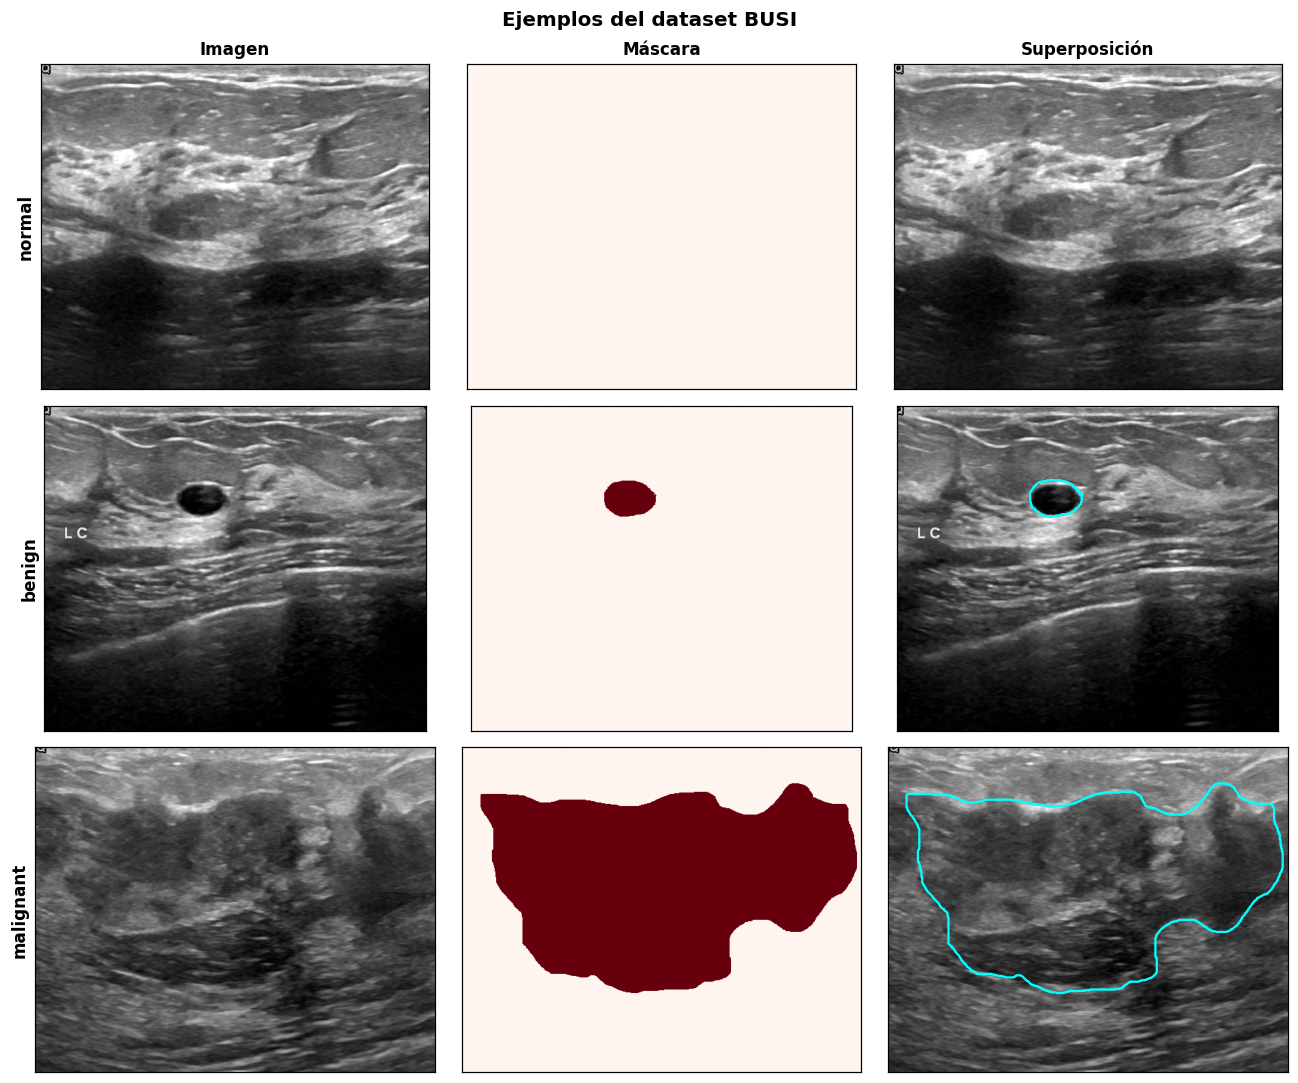

In [2]:
KAGGLE_ROOT = (
    Path("/kaggle") if "KAGGLE_KERNEL_RUN_TYPE" in os.environ else Path("./kaggle")
)

US_DATASET_NAME = "aryashah2k/breast-ultrasound-images-dataset"
US_DATASET_PATH = KAGGLE_ROOT / "input" / "datasets" / US_DATASET_NAME
US_DATA_PATH = US_DATASET_PATH / "Dataset_BUSI_with_GT"

US_CLASSES = ["normal", "benign", "malignant"]
for cls in US_CLASSES:
    cls_dir = US_DATA_PATH / cls
    imgs = (
        [p for p in cls_dir.glob("*.png") if "_mask" not in p.name]
        if cls_dir.exists()
        else []
    )
    print(f"  {cls}: {len(imgs)} imágenes")

# ── Ejemplos visuales ────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for ax, t in zip(axes[0], ["Imagen", "Máscara", "Superposición"]):
    ax.set_title(t, fontweight="bold", fontsize=11)

for row, cls in enumerate(US_CLASSES):
    cls_dir = US_DATA_PATH / cls
    candidates = [p for p in cls_dir.glob("*.png") if "_mask" not in p.name]
    img_p = random.choice(candidates)
    mask_p = img_p.with_name(img_p.stem + "_mask.png")

    img = np.array(Image.open(img_p).convert("L"))
    has_mask = mask_p.exists()
    mask = np.array(Image.open(mask_p).convert("L")) if has_mask else np.zeros_like(img)

    axes[row, 0].imshow(img, cmap="gray")
    axes[row, 0].set_ylabel(cls, fontsize=11, fontweight="bold")
    axes[row, 1].imshow(mask, cmap="Reds")
    axes[row, 2].imshow(img, cmap="gray")
    if has_mask and mask.max() > 0:
        axes[row, 2].contour(mask > 127, colors="cyan", linewidths=1.5)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("Ejemplos del dataset BUSI", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Observa cómo las imágenes **normal** carecen de lesión (máscara vacía), mientras que las clases **benign** y **malignant** presentan regiones tumorales delimitadas. Las lesiones malignas tienden a mostrar bordes más irregulares y ecotextura más heterogénea.

<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='monai04'></a>

## <span style="color: #667eea;">Segmentación Clásica con MONAI</span>

[MONAI](https://project-monai.github.io/) (Medical Open Network for AI) es un framework open-source basado en PyTorch, desarrollado por NVIDIA y la comunidad, diseñado específicamente para deep learning en imagen médica. Proporciona herramientas optimizadas para construir pipelines completos de IA médica, desde la carga y preprocesamiento de datos hasta el entrenamiento y evaluación de modelos.

El core de MONAI incluye componentes especializados para trabajar con imágenes médicas:

- **Transforms**: transformaciones específicas para imagen médica (resampling, normalización, data augmentation 3D).
- **Networks**: arquitecturas adaptadas al dominio biomédico como UNet, DenseNet o Vision Transformers.
- **Losses & Metrics**: funciones de pérdida (DiceLoss, FocalLoss) y métricas (Dice, Hausdorff) diseñadas para tareas clínicas.
- **Data**: utilidades para cargar y gestionar volúmenes médicos (NIfTI, DICOM) mediante datasets y dataloaders optimizados.

Además del core framework, MONAI forma parte de un ecosistema más amplio que incluye herramientas como MONAI Bundles (modelos empaquetados reproducibles), MONAI Label (anotación interactiva asistida por IA) o MONAI Deploy (despliegue en entornos clínicos).

En esta sección construiremos un pipeline supervisado de segmentación con **DynUNet** utilizando el dataset **BUSI** y únicamente el core de MONAI. Este pipeline servirá como referencia de segmentación supervisada clásica, antes de explorar métodos de segmentación interactiva como MedSAM.

### *Preparación de datos*

Antes de entrenar, necesitamos construir un pipeline de datos con MONAI. Los pasos son:


1. **Pares imagen-máscara**: recorremos las carpetas `benign` y `malignant` para emparejar cada imagen PNG con su máscara `_mask.png` correspondiente.

2. **Transforms**: definimos un pipeline de preprocesamiento que redimensiona las imágenes a 128×128, normaliza las intensidades y, durante el entrenamiento, aplica data augmentation (flips y rotaciones aleatorias).

3. **Dataset y DataLoaders**: encapsulamos los datos en un `Dataset` de PyTorch y creamos los loaders para entrenamiento y validación.

In [3]:
from monai.data import DataLoader
from monai.transforms import (
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    Lambdad,
    NormalizeIntensityd,
    RandFlipd,
    RandRotate90d,
    Resized,
    ScaleIntensityd,
)

# ── Pares imagen-máscara ──────────────────────────────────────────────────────
seg_data = []

for cls in ["benign", "malignant"]:
    cls_dir = US_DATA_PATH / cls
    for img_p in sorted(cls_dir.glob("*.png")):
        if "_mask" in img_p.name:
            continue
        mask_p = img_p.with_name(img_p.stem + "_mask.png")
        if mask_p.exists():
            seg_data.append({"image": str(img_p), "mask": str(mask_p)})

rng = random.Random(GLOBAL_SEED)
rng.shuffle(seg_data)

if len(seg_data) == 0:
    raise RuntimeError(
        "No se encontraron pares imagen-máscara en BUSI. Revisa US_DATA_PATH."
    )

print(f"Total pares imagen-máscara: {len(seg_data)}")

# ── Transforms y Dataset ──────────────────────────────────────────────────────
SEG_IMG_SIZE = 128
TRAIN_VAL_SPLIT = 0.8  # 80 % entrenamiento, 20 % validación


def build_seg_transforms(augment=False, img_size=SEG_IMG_SIZE):
    transforms = [
        EnsureChannelFirstd(keys=["image", "mask"], channel_dim="no_channel"),
        Resized(
            keys=["image", "mask"],
            spatial_size=(img_size, img_size),
            mode=("bilinear", "nearest"),
        ),
        ScaleIntensityd(keys=["image"]),
        NormalizeIntensityd(keys=["image"], nonzero=False, channel_wise=True),
    ]
    if augment:
        transforms += [
            RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=0),
            RandFlipd(keys=["image", "mask"], prob=0.5, spatial_axis=1),
            RandRotate90d(keys=["image", "mask"], prob=0.5, max_k=3),
        ]
    transforms += [
        Lambdad(keys=["mask"], func=lambda x: (x > 0.5).astype(np.float32)),
        EnsureTyped(keys=["image", "mask"], dtype=torch.float32),
    ]
    return Compose(transforms)


class BUSISegDataset(torch.utils.data.Dataset):
    def __init__(self, data_list, transform):
        self.data = data_list
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = np.array(Image.open(item["image"]).convert("L"), dtype=np.float32)
        mask = np.array(Image.open(item["mask"]).convert("L"), dtype=np.float32)
        sample = self.transform({"image": image, "mask": mask})
        return sample["image"], sample["mask"]


# ── Splits y DataLoaders ──────────────────────────────────────────────────────
if len(seg_data) < 2:
    raise RuntimeError("Se necesitan al menos 2 pares para train/val en segmentación.")

n_train_seg = max(1, int(len(seg_data) * TRAIN_VAL_SPLIT))
n_val_seg = len(seg_data) - n_train_seg

train_seg = seg_data[:n_train_seg]
val_seg = seg_data[n_train_seg:]

train_ds = BUSISegDataset(train_seg, transform=build_seg_transforms(augment=True))
val_ds = BUSISegDataset(val_seg, transform=build_seg_transforms(augment=False))

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8, shuffle=False)

print(
    f"Split {int(TRAIN_VAL_SPLIT * 100)}/{int((1 - TRAIN_VAL_SPLIT) * 100)} — Train: {len(train_ds)} muestras | Val: {len(val_ds)} muestras"
)

Total pares imagen-máscara: 647
Split 80/19 — Train: 517 muestras | Val: 130 muestras


<a class='anchor' id='dynunet04'></a>

### *Entrenamiento DynUNet*

**DynUNet** es la implementación de MONAI de una UNet con configuración dinámica de kernels y strides. Permite definir de forma flexible el número de niveles y el tipo de downsampling, pero sigue siendo una UNet — no debe confundirse con el framework nnU-Net (que es un sistema independiente con autoconfiguración del pipeline completo).

El modelo se entrena durante 20 épocas con Adam (lr = 1e-3), mostrando el progreso tras cada época.

El pipeline de entrenamiento utiliza:

- **Early checkpoint**: se guarda el estado del modelo con mejor Dice en validación.

- **DiceCELoss**: combinación de Dice Loss y Cross-Entropy, que equilibra la penalización por solapamiento global y por píxel.
- **DiceMetric**: coeficiente Dice sobre el conjunto de validación para monitorizar el rendimiento.

In [4]:
from monai.networks.nets import DynUNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.transforms import Activations, AsDiscrete
import copy


# Para imágenes 2D de 128×128 usamos 3 niveles con downsampling ×2.
KERNELS = [[3, 3], [3, 3], [3, 3]]
STRIDES = [[1, 1], [2, 2], [2, 2]]

dynunet_model = DynUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    kernel_size=KERNELS,
    strides=STRIDES,
    upsample_kernel_size=STRIDES[1:],
    norm_name="instance",
    deep_supervision=False,
).to(device)

loss_fn_dyn = DiceCELoss(sigmoid=True)
optimizer_dyn = torch.optim.Adam(dynunet_model.parameters(), lr=1e-3)
dice_metric_dyn = DiceMetric(include_background=True, reduction="mean")

# Post-procesado para métricas y visualización (sigmoid + umbral 0.5)
post_pred = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

n_params_dyn = sum(p.numel() for p in dynunet_model.parameters() if p.requires_grad)
print(f"DynUNet parámetros entrenables: {n_params_dyn:,}")

NUM_EPOCHS_DYN = (
    20  # limitamos el número de épocas a 20 para acortar el tiempo de entrenamiento
)
train_losses_dyn = []
val_dices_dyn = []
best_val_dice_dyn = -1.0
best_epoch_dyn = -1
best_dynunet_state = None

best_dynunet_path = Path("kaggle/working/dynunet_best_val.pth")
best_dynunet_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(NUM_EPOCHS_DYN):
    dynunet_model.train()
    epoch_loss_dyn = 0.0

    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer_dyn.zero_grad()
        logits = dynunet_model(imgs)
        loss = loss_fn_dyn(logits, masks)
        loss.backward()
        optimizer_dyn.step()
        epoch_loss_dyn += loss.item()

    epoch_loss_dyn /= max(1, len(train_loader))
    train_losses_dyn.append(epoch_loss_dyn)

    dynunet_model.eval()
    dice_metric_dyn.reset()
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            logits = dynunet_model(imgs)
            preds = post_pred(logits)
            dice_metric_dyn(preds, masks)

    val_dice_dyn = float(dice_metric_dyn.aggregate().item())
    val_dices_dyn.append(val_dice_dyn)

    if val_dice_dyn > best_val_dice_dyn:
        best_val_dice_dyn = val_dice_dyn
        best_epoch_dyn = epoch + 1
        best_dynunet_state = copy.deepcopy(dynunet_model.state_dict())
        torch.save(best_dynunet_state, best_dynunet_path)

    print(
        f"Epoch {epoch + 1:3d}/{NUM_EPOCHS_DYN} | Loss: {epoch_loss_dyn:.4f} | Val Dice: {val_dice_dyn:.4f}"
    )


if best_dynunet_state is not None:
    print(f"Checkpoint guardado en: {best_dynunet_path}")
    dynunet_model.load_state_dict(best_dynunet_state)
    print(
        f"\nMejor Dice en validación (DynUNet): {best_val_dice_dyn:.4f} (epoch {best_epoch_dyn})"
    )

DynUNet parámetros entrenables: 465,217
Epoch   1/20 | Loss: 1.2884 | Val Dice: 0.3247
Epoch   2/20 | Loss: 1.0700 | Val Dice: 0.4066
Epoch   3/20 | Loss: 0.9882 | Val Dice: 0.4564
Epoch   4/20 | Loss: 0.9290 | Val Dice: 0.4711
Epoch   5/20 | Loss: 0.8919 | Val Dice: 0.4718
Epoch   6/20 | Loss: 0.8570 | Val Dice: 0.4844
Epoch   7/20 | Loss: 0.8372 | Val Dice: 0.5183
Epoch   8/20 | Loss: 0.8106 | Val Dice: 0.5313
Epoch   9/20 | Loss: 0.8071 | Val Dice: 0.5468
Epoch  10/20 | Loss: 0.7853 | Val Dice: 0.5670
Epoch  11/20 | Loss: 0.7505 | Val Dice: 0.5791
Epoch  12/20 | Loss: 0.7358 | Val Dice: 0.6091
Epoch  13/20 | Loss: 0.7063 | Val Dice: 0.5984
Epoch  14/20 | Loss: 0.7041 | Val Dice: 0.6364
Epoch  15/20 | Loss: 0.6742 | Val Dice: 0.6287
Epoch  16/20 | Loss: 0.6486 | Val Dice: 0.6716
Epoch  17/20 | Loss: 0.6270 | Val Dice: 0.6784
Epoch  18/20 | Loss: 0.6147 | Val Dice: 0.6453
Epoch  19/20 | Loss: 0.6253 | Val Dice: 0.6815
Epoch  20/20 | Loss: 0.6080 | Val Dice: 0.6776
Checkpoint guardado 

### *Resultados*

Visualizamos la evolución del entrenamiento mediante dos curvas (pérdida y Dice por época) y comparamos visualmente las predicciones de DynUNet con el ground truth sobre muestras del conjunto de validación.


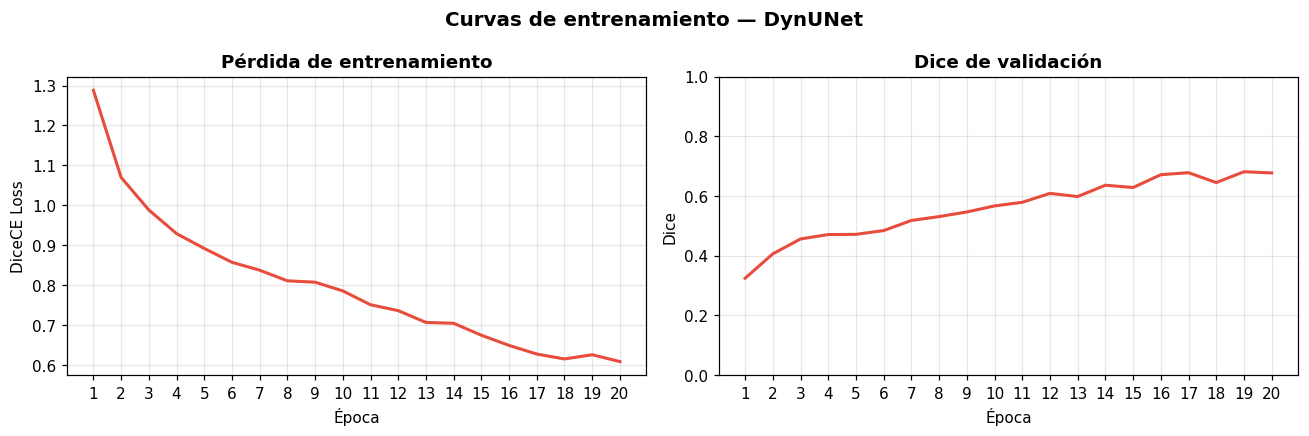

In [5]:
# ── Curvas de entrenamiento ───────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = list(range(1, NUM_EPOCHS_DYN + 1))

ax1.plot(epochs, train_losses_dyn, color="#e74c3c", linewidth=2)
ax1.set_xlabel("Época")
ax1.set_ylabel("DiceCE Loss")
ax1.set_title("Pérdida de entrenamiento", fontweight="bold")
ax1.grid(alpha=0.3)
ax1.set_xticks(epochs)

ax2.plot(epochs, val_dices_dyn, color="#e74c3c", linewidth=2)
ax2.set_xlabel("Época")
ax2.set_ylabel("Dice")
ax2.set_ylim(0, 1)
ax2.set_title("Dice de validación", fontweight="bold")
ax2.grid(alpha=0.3)
ax2.set_xticks(epochs)

plt.suptitle("Curvas de entrenamiento — DynUNet", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

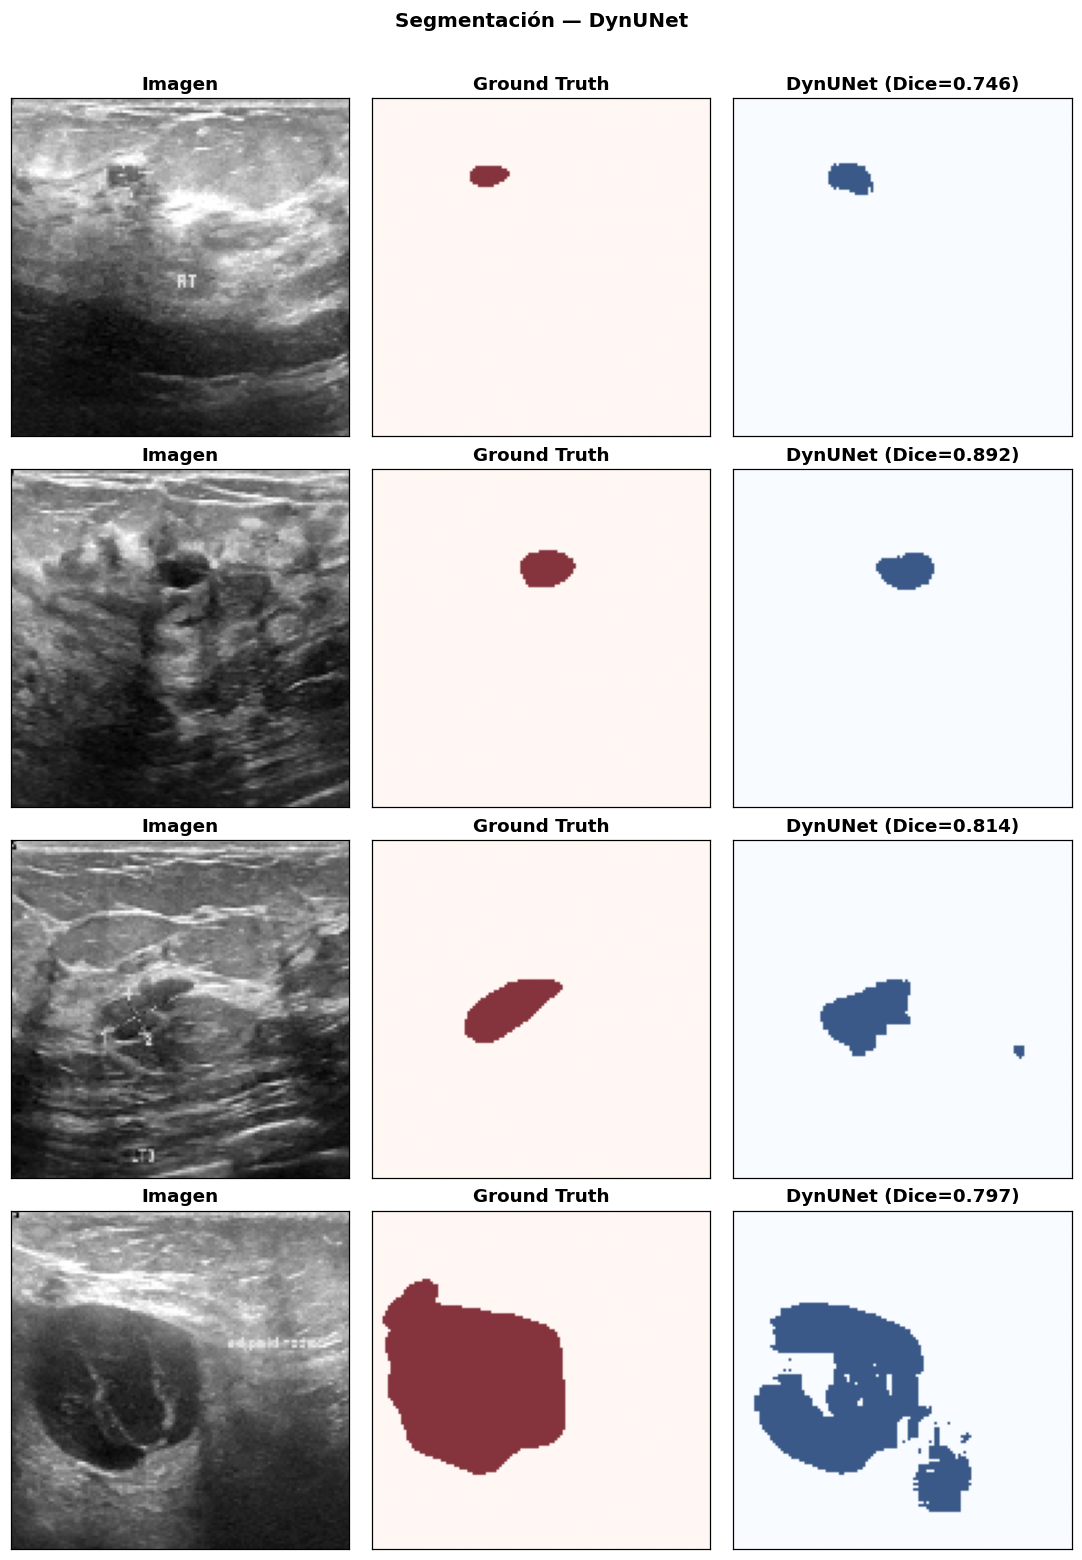

Mejor Dice en validación (DynUNet): 0.6815  (epoch 19)


In [6]:
# ── Resultados cualitativos ───────────────────────────────────────────────────
dynunet_model.eval()

n_show = min(4, len(val_ds))
fig, axes_r = plt.subplots(n_show, 3, figsize=(10, 3.5 * n_show))
axes_r = np.atleast_2d(axes_r)


def to_np(t):
    return (t.squeeze().cpu().numpy() > 0.5).astype(float)


def dice_score(pred, gt):
    pred = np.asarray(pred, dtype=bool)
    gt = np.asarray(gt, dtype=bool)
    if gt.sum() == 0 and pred.sum() == 0:
        return 1.0
    return 2.0 * (pred & gt).sum() / (pred.sum() + gt.sum() + 1e-8)


for i in range(n_show):
    img_t, mask_t = val_ds[i]
    inp = img_t.unsqueeze(0).to(device)

    with torch.no_grad():
        pred_dyn = torch.sigmoid(dynunet_model(inp))

    pred_dyn_np = to_np(pred_dyn)
    img_np = img_t.squeeze().numpy()
    mask_np = mask_t.squeeze().numpy()
    d_dyn = dice_score(pred_dyn_np, mask_np)

    axes_r[i, 0].imshow(img_np, cmap="gray")
    axes_r[i, 0].set_title("Imagen", fontweight="bold")
    axes_r[i, 1].imshow(mask_np, cmap="Reds", alpha=0.8)
    axes_r[i, 1].set_title("Ground Truth", fontweight="bold")
    axes_r[i, 2].imshow(pred_dyn_np, cmap="Blues", alpha=0.8)
    axes_r[i, 2].set_title(f"DynUNet (Dice={d_dyn:.3f})", fontweight="bold")

    for ax in axes_r[i]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle("Segmentación — DynUNet", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()

plt.show()

print(
    f"Mejor Dice en validación (DynUNet): {best_val_dice_dyn:.4f}  (epoch {best_epoch_dyn})"
)

Los resultados muestran que la segmentación supervisada en ecografía mamaria es una tarea exigente: aunque en algunos casos DynUNet logra valores de Dice altos, en otros aparecen problemas de sobresegmentación o localización incorrecta. Esto se debe al bajo contraste, los bordes difusos y el ruido speckle característicos de esta modalidad.

En la siguiente sección veremos cómo la **segmentación interactiva** con MedSAM aborda este problema desde otro ángulo, incorporando información del usuario (punto o caja) para guiar la predicción.

<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='medsam04'></a>

## <span style="color: #667eea;">Segmentación Interactiva: MedSAM</span>

En la sección anterior hemos construido un pipeline clásico de segmentación supervisada con MONAI. Ahora exploraremos un paradigma diferente: la **segmentación interactiva con prompts**.

[MedSAM](https://github.com/bowang-lab/MedSAM) adapta **Segment Anything Model (SAM)** al dominio médico. Fue entrenado sobre **~1.5 millones de pares imagen-máscara** de 11 modalidades (CT, MRI, ecografía, rayos X, dermatoscopia, endoscopia, etc.), lo que le permite segmentar estructuras anatómicas y lesiones sin entrenamiento específico por tarea. Su arquitectura consta de tres componentes:

- **Image Encoder** (ViT-B): extrae features visuales de la imagen completa.
- **Prompt Encoder**: codifica el prompt del usuario (punto, caja o máscara) en embeddings espaciales.
- **Mask Decoder**: combina ambas representaciones para generar la máscara de segmentación.

A diferencia de la DynUNet que acabamos de entrenar, MedSAM no requiere entrenamiento sobre un dataset específico — es un *foundation model* que genera la segmentación a partir de una interacción del usuario:

| | **DynUNet** (supervisado) | **MedSAM** (interactivo) |
| :--- | :--- | :--- |
| Entrenamiento | Necesario, específico por tarea | No necesario (*foundation model*) |
| Datos etiquetados | Requiere pares imagen-máscara | No (usa prompts en tiempo de inferencia) |
| Generalización | Limitada al dominio de entrenamiento | Amplia (~1.5M imágenes médicas) |
| Interacción | Automática (sin intervención humana) | Requiere prompt del usuario |

En esta sección cargaremos MedSAM, segmentaremos lesiones mamarias del dataset **BUSI** usando prompts de **punto** y de **caja**, e interactuaremos con el modelo en tiempo real a través de un widget interactivo.

### *Carga del modelo*

Descargamos el checkpoint `wanglab/medsam-vit-base` desde HuggingFace mediante la librería `transformers`. El modelo utiliza un encoder ViT-B (86M parámetros) y puede ejecutarse en GPU como T4 o P100.

In [7]:
from transformers import SamModel, SamProcessor

print(f"Dispositivo: {device}")

model_name = "wanglab/medsam-vit-base"
print(f"Cargando {model_name}...")

processor = SamProcessor.from_pretrained(model_name)
model = SamModel.from_pretrained(model_name).to(device)
model.eval()

print("MedSAM cargado correctamente.")

Dispositivo: cuda
Cargando wanglab/medsam-vit-base...


The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/315 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared_image_embedding.positional_embedding to prompt_encoder.shared_embedding.positional_embedding, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


MedSAM cargado correctamente.


### *Funciones auxiliares*

Para evaluar MedSAM necesitamos simular la interacción del usuario. Definimos tres funciones que generan prompts automáticos a partir del ground truth y encapsulan la inferencia:

- `prompt_point_from_mask` — calcula el **centroide** de la lesión como prompt de punto.
- `prompt_box_from_mask` — extrae la **bounding box** con un margen de seguridad.
- `segment_with_prompt` — ejecuta la inferencia de MedSAM dado un prompt (punto o caja).

Para medir la calidad de la segmentación reutilizamos la función `dice_score` definida en la sección anterior.

In [8]:
def prompt_point_from_mask(mask):
    ys, xs = np.where(mask > 0)
    if len(ys) == 0:
        return None
    cy, cx = int(ys.mean()), int(xs.mean())
    return [[cx, cy]]


def prompt_box_from_mask(mask, margin=5):
    ys, xs = np.where(mask > 0)
    if len(ys) == 0:
        return None
    y0 = max(0, int(ys.min()) - margin)
    x0 = max(0, int(xs.min()) - margin)
    y1 = min(mask.shape[0], int(ys.max()) + margin)
    x1 = min(mask.shape[1], int(xs.max()) + margin)
    return [[x0, y0, x1, y1]]


def segment_with_prompt(model, processor, image_rgb, prompt_type, prompt_value, device):
    if prompt_type == "point":
        inputs = processor(
            image_rgb, input_points=[prompt_value], return_tensors="pt"
        ).to(device)
    elif prompt_type == "box":
        inputs = processor(
            image_rgb, input_boxes=[prompt_value], return_tensors="pt"
        ).to(device)
    else:
        raise ValueError(f"Tipo de prompt no soportado: {prompt_type}")

    # Inference mode evita crear grafo y autocast reduce el pico de VRAM en CUDA.
    with torch.inference_mode():
        if device == "cuda":
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                outputs = model(**inputs)
        else:
            outputs = model(**inputs)

    masks = processor.image_processor.post_process_masks(
        outputs.pred_masks.float().cpu(),
        inputs["original_sizes"].cpu(),
        inputs["reshaped_input_sizes"].cpu(),
    )
    pred = masks[0][0, 0].numpy() > 0.5

    del outputs, inputs, masks
    if device == "cuda":
        torch.cuda.empty_cache()

    return pred

### *Ejemplos: punto vs. caja*

¿Qué ocurre cuando cambiamos el tipo de prompt? Para comprobarlo, segmentamos una lesión benigna y una maligna con ambos modos, usando prompts generados automáticamente a partir del ground truth (centroide para el punto, bounding box con margen para la caja). En cada caso se muestra la predicción de MedSAM (contorno cyan), el prompt utilizado (cruz roja o caja roja) y el Dice respecto a la máscara real.

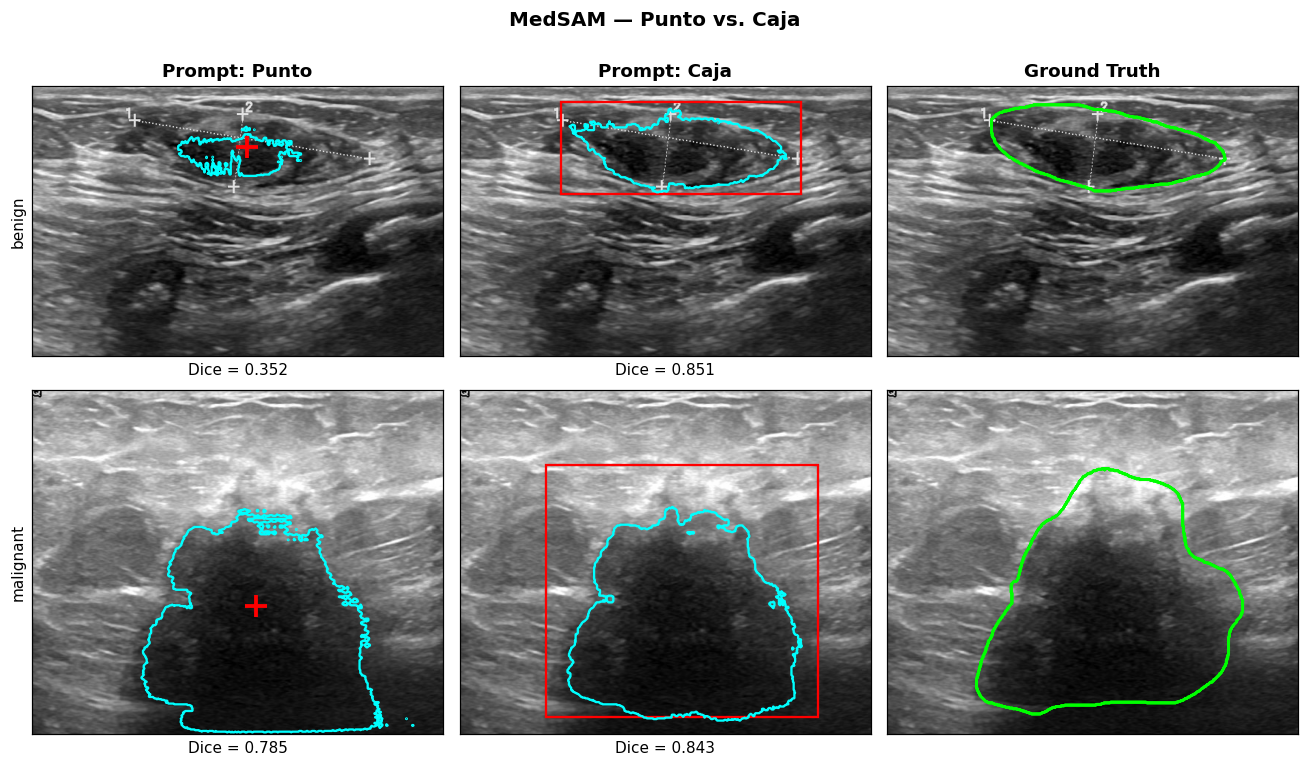

In [9]:
from matplotlib.patches import Rectangle

# Una muestra benign y una malignant de seg_data
samples = [
    next(d for d in seg_data if "benign" in d["image"]),
    next(d for d in seg_data if "malignant" in d["image"]),
]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle("MedSAM — Punto vs. Caja", fontsize=13, fontweight="bold")
for ax, title in zip(axes[0], ["Prompt: Punto", "Prompt: Caja", "Ground Truth"]):
    ax.set_title(title, fontweight="bold")

for row, d in enumerate(samples):
    img = Image.open(d["image"]).convert("RGB")
    img_np = np.array(img)
    mask = (np.array(Image.open(d["mask"]).convert("L")) > 127).astype(np.uint8)
    cls = Path(d["image"]).parent.name

    pt = prompt_point_from_mask(mask)
    bx = prompt_box_from_mask(mask)
    pred_pt = segment_with_prompt(model, processor, img, "point", [pt], device)
    pred_bx = segment_with_prompt(model, processor, img, "box", [bx], device)

    # Punto
    axes[row, 0].imshow(img_np)
    axes[row, 0].contour(pred_pt, colors="cyan", linewidths=1.5)
    axes[row, 0].plot(pt[0][0], pt[0][1], "r+", ms=14, mew=2.5)
    axes[row, 0].set_ylabel(cls, fontsize=10)
    axes[row, 0].set_xlabel(f"Dice = {dice_score(pred_pt, mask):.3f}")

    # Caja
    b = bx[0]
    axes[row, 1].imshow(img_np)
    axes[row, 1].contour(pred_bx, colors="cyan", linewidths=1.5)
    axes[row, 1].add_patch(
        Rectangle((b[0], b[1]), b[2] - b[0], b[3] - b[1], ec="red", fc="none", lw=1.5)
    )
    axes[row, 1].set_xlabel(f"Dice = {dice_score(pred_bx, mask):.3f}")

    # Ground Truth
    axes[row, 2].imshow(img_np)
    axes[row, 2].contour(mask, colors="lime", linewidths=1.5)

for ax in axes.flat:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

El **prompt de caja** tiende a producir Dice más altos y segmentaciones más estables, especialmente en lesiones grandes o con bordes irregulares. La caja delimita la escala y ubicación de la estructura, mientras que el punto solo marca el centro aproximado, dejando más margen a la ambigüedad. No obstante, en lesiones pequeñas y bien definidas, ambos prompts pueden dar resultados comparables.

### *Widget interactivo*

La siguiente celda lanza una demo construida con [Gradio](https://www.gradio.app/), una librería que puedes utilizar para generar interfaces web interactivas directamente desde Python. La interfaz se mostrará embebida en el notebook, pero también puedes abrirla en una pestaña del navegador usando el enlace que aparece en la salida para una experiencia más cómoda.

Selecciona una imagen del dropdown, elige el tipo de prompt (Punto o Caja) y haz clic sobre la imagen: con **Punto** basta un clic; con **Caja** necesitas dos clics (esquinas opuestas del rectángulo). MedSAM generará la segmentación y mostrará el Dice respecto al ground truth.

In [10]:
import gradio as gr
import cv2

# ── Catálogo de imágenes ────────────────────────────────────────────────────
img_catalog = {}
for cls in ["benign", "malignant"]:
    for p in sorted((US_DATA_PATH / cls).glob("*.png")):
        if "_mask" not in p.name:
            mask_p = p.with_name(p.stem + "_mask.png")
            if mask_p.exists():
                img_catalog[f"{cls} / {p.name}"] = (p, mask_p, cls)


# ── Helpers ─────────────────────────────────────────────────────────────────
def _contour_overlay(img, mask, color, thick=2):
    vis = img.copy()
    m = mask.astype(np.uint8) if mask.dtype != np.uint8 else mask
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(vis, cnts, -1, color, thick)
    return vis


# ── Callbacks ───────────────────────────────────────────────────────────────
def on_image_change(key):
    """Carga imagen + GT al cambiar el dropdown."""
    if key is None:
        return None, None, None, None, None, [], ""
    p_img, p_mask, cls = img_catalog[key]
    pil = Image.open(p_img).convert("RGB")
    arr = np.array(pil)
    gt = (np.array(Image.open(p_mask).convert("L")) > 127).astype(np.uint8)
    gt_vis = _contour_overlay(arr, gt, color=(0, 255, 0))
    return arr, arr.copy(), gt_vis, pil, gt, [], f"**Clase: {cls}**"


def on_click(prompt, box_clicks, pil_orig, gt_mask, evt: gr.SelectData):
    """Procesa click: punto directo o acumula 2 esquinas para caja."""
    if pil_orig is None:
        return None, None, box_clicks, ""

    arr = np.array(pil_orig)
    draw = arr.copy()
    x, y = evt.index  # (col, row)

    # ── Modo Punto ──
    if prompt == "Punto":
        cv2.drawMarker(draw, (x, y), (255, 50, 50), cv2.MARKER_CROSS, 20, 3)
        pred = segment_with_prompt(
            model, processor, pil_orig, "point", [[[x, y]]], device
        )
        d = dice_score(pred, gt_mask)
        pred_vis = _contour_overlay(arr, pred, color=(0, 255, 255))
        return draw, pred_vis, [], f"**Dice = {d:.3f}**"

    # ── Modo Caja ──
    box_clicks = list(box_clicks) + [(x, y)]

    if len(box_clicks) == 1:  # primer click
        cv2.circle(draw, (x, y), 5, (255, 50, 50), -1)
        return draw, arr, box_clicks, "*Haz click en la 2ª esquina…*"

    # segundo click → inferencia
    x0, y0 = box_clicks[0]
    x1, y1 = box_clicks[1]
    box = [min(x0, x1), min(y0, y1), max(x0, x1), max(y0, y1)]
    cv2.rectangle(draw, (box[0], box[1]), (box[2], box[3]), (255, 50, 50), 2)

    pred = segment_with_prompt(model, processor, pil_orig, "box", [box], device)
    d = dice_score(pred, gt_mask)
    pred_vis = _contour_overlay(arr, pred, color=(0, 255, 255))
    return draw, pred_vis, [], f"**Dice = {d:.3f}**"


# ── Interfaz ────────────────────────────────────────────────────────────────
with gr.Blocks(theme=gr.themes.Soft(), title="MedSAM Demo") as demo:
    gr.Markdown("## Demo interactiva — MedSAM sobre BUSI")

    pil_state = gr.State(None)
    gt_state = gr.State(None)
    box_state = gr.State([])

    with gr.Row():
        dd = gr.Dropdown(sorted(img_catalog), label="Imagen", scale=3, value=None)
        radio = gr.Radio(["Punto", "Caja"], value="Punto", label="Prompt", scale=1)

    info_md = gr.Markdown("")

    with gr.Row(equal_height=True):
        img_in = gr.Image(label="Input — click aquí")
        img_pred = gr.Image(label="MedSAM")
        img_gt = gr.Image(label="Ground Truth")

    dice_md = gr.Markdown("")

    # ── Conexiones ──
    dd.change(
        on_image_change,
        inputs=[dd],
        outputs=[img_in, img_pred, img_gt, pil_state, gt_state, box_state, info_md],
    )
    radio.change(lambda: [], outputs=[box_state])  # reset caja pendiente

    img_in.select(
        on_click,
        inputs=[radio, box_state, pil_state, gt_state],
        outputs=[img_in, img_pred, box_state, dice_md],
    )

demo.launch(quiet=True, share=("KAGGLE_URL_BASE" in os.environ), height=800)

/tmp/ipykernel_680186/3068774263.py:75: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(), title="MedSAM Demo") as demo:


Como verás, Gradio genera una interfaz web interactiva directamente dentro del notebook. Cuando termines de experimentar, ejecuta la siguiente celda para liberar el puerto y detener el servidor.

In [11]:
demo.close()
print("Gradio detenido")

Closing server running on port: 7860
Gradio detenido


<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='radiomica04'></a>

## <span style="color: #667eea;">Radiómica con PyRadiomics</span>

La radiómica extrae **features matemáticos** de la región de interés (ROI) a partir de la imagen y su máscara. Estos features cuantifican propiedades de **forma**, **intensidad** y **textura** que el ojo humano no puede medir con precisión.

En esta sección extraeremos features radiómicos de las lesiones mamarias, compararemos sus distribuciones entre clases y entrenaremos un clasificador simple para distinguir benigno de maligno.

### *Extracción de features radiómicos*

La **radiómica** convierte cada lesión segmentada en un vector numérico interpretable. En este bloque usamos **PyRadiomics** para tres familias de descriptores:

- **First-order**: resumen la distribución de intensidades dentro de la lesión (media, desviación, asimetría, entropía).
- **Shape2D**: cuantifican la geometría del contorno (área, perímetro, circularidad, elongación/compacidad).
- **GLCM (textura)**: miden patrones espaciales de gris (contraste, homogeneidad, correlación), útiles para capturar heterogeneidad intralesional.

A diferencia de las features profundas, estas variables son explícitas y facilitan la interpretación de qué rasgos morfológicos y texturales diferencian lesiones **benignas** y **malignas**.


In [12]:
import SimpleITK as sitk
import radiomics

radiomics.setVerbosity(40)
from radiomics import featureextractor
import pandas as pd

settings = {
    "binWidth": 25,
    "resampledPixelSpacing": None,
    "interpolator": sitk.sitkBSpline,
    "force2D": True,
}
extractor = featureextractor.RadiomicsFeatureExtractor(**settings)
extractor.disableAllFeatures()
extractor.enableFeatureClassByName("firstorder")
extractor.enableFeatureClassByName("shape2D")
extractor.enableFeatureClassByName("glcm")

print("Feature classes habilitadas:", extractor.enabledFeatures)


def extract_features(img_path, mask_path):
    img = np.array(Image.open(img_path).convert("L")).astype(np.float64)
    mask = np.array(Image.open(mask_path).convert("L"))
    mask = (mask > 127).astype(np.uint8)
    if mask.sum() < 10:
        return None
    img_sitk = sitk.GetImageFromArray(img)
    mask_sitk = sitk.GetImageFromArray(mask)
    try:
        result = extractor.execute(img_sitk, mask_sitk)
        feats = {
            k: float(v) for k, v in result.items() if not k.startswith("diagnostics")
        }
        return feats
    except Exception:
        return None


rows = []
for cls in ["benign", "malignant"]:
    cls_dir = US_DATA_PATH / cls
    for img_p in cls_dir.glob("*.png"):
        if "_mask" in img_p.name:
            continue
        mask_p = img_p.with_name(img_p.stem + "_mask.png")
        if not mask_p.exists():
            continue
        feats = extract_features(img_p, mask_p)
        if feats is not None:
            feats["class"] = cls
            feats["file"] = img_p.name
            rows.append(feats)

df = pd.DataFrame(rows)
feat_cols = [c for c in df.columns if c not in ["class", "file"]]
print(f"Imágenes procesadas: {len(df)}")
print(f"Features extraídos: {len(feat_cols)}")
print(
    f"  benign: {(df['class'] == 'benign').sum()}, malignant: {(df['class'] == 'malignant').sum()}"
)

Feature classes habilitadas: {'firstorder': [], 'shape2D': [], 'glcm': []}
Imágenes procesadas: 647
Features extraídos: 51
  benign: 437, malignant: 210


### *Distribución de features por clase*

Visualizamos las distribuciones de cuatro features representativos (uno de forma, uno de textura y dos de intensidad). Si las distribuciones de benigno y maligno están bien separadas, el feature tiene potencial discriminativo; si se solapan mucho, aporta poca información para la clasificación.

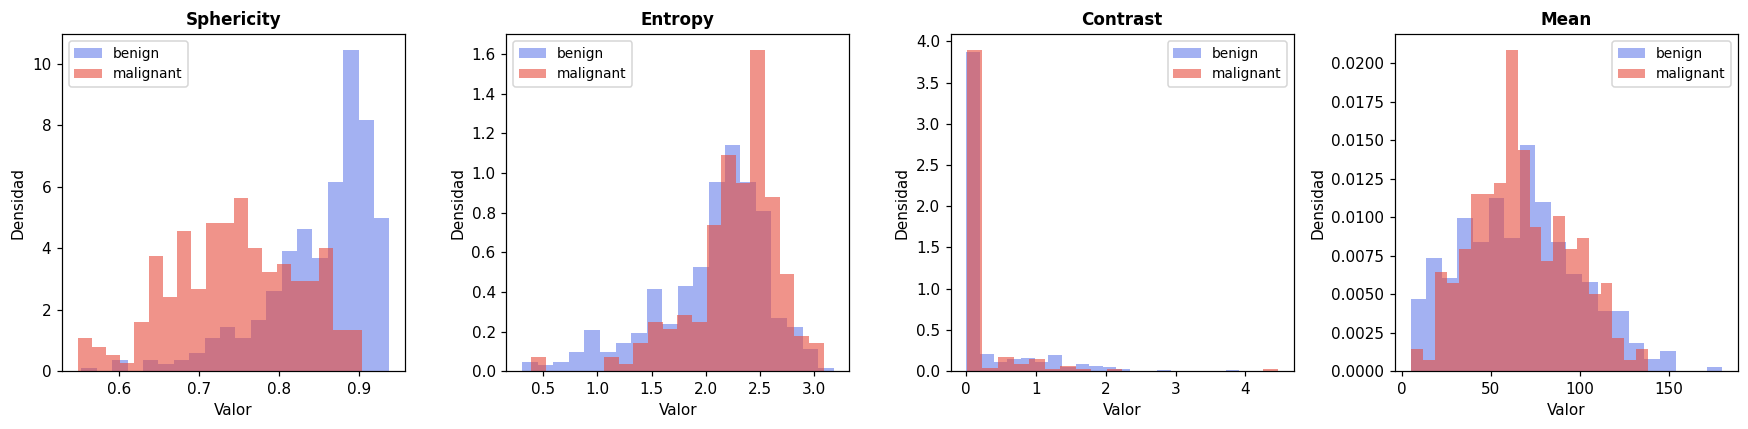

In [13]:
selected = [
    "original_shape2D_Sphericity",
    "original_firstorder_Entropy",
    "original_glcm_Contrast",
    "original_firstorder_Mean",
]
selected = [f for f in selected if f in feat_cols]

fig, axes = plt.subplots(1, len(selected), figsize=(4 * len(selected), 4))
if len(selected) == 1:
    axes = [axes]

for ax, feat in zip(axes, selected):
    for cls, color in [("benign", "#667eea"), ("malignant", "#e74c3c")]:
        vals = df[df["class"] == cls][feat].dropna()
        ax.hist(vals, bins=20, alpha=0.6, label=cls, color=color, density=True)
    short_name = feat.split("_")[-1]
    ax.set_title(short_name, fontsize=11, fontweight="bold")
    ax.legend(fontsize=9)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidad")

plt.tight_layout()
plt.show()

¿Qué features muestran mayor separación entre clases? ¿Los más discriminativos son de forma, intensidad o textura? Fíjate también en los que se solapan casi por completo — ¿significa que son inútiles, o podrían aportar información complementaria cuando se combinan con otros?

### *Clasificador con regularización L1*

Los histogramas anteriores sugieren que algunos features separan razonablemente las clases, pero ¿es suficiente para distinguir benigno de maligno de forma automática? Para comprobarlo, entrenamos un clasificador simple: una **Regresión Logística con penalización L1**.

¿Por qué L1 y no L2? La penalización L1 (*Lasso*) fuerza a que muchos coeficientes sean exactamente cero, realizando **selección automática de features**: el modelo descarta los descriptores irrelevantes y retiene solo los más discriminativos. Esto es especialmente útil en radiómica, donde el número de features puede superar al de muestras.

Evaluamos con **AUC** en validación cruzada de 5 folds.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

X = df[feat_cols].fillna(0).values
y = (df["class"] == "malignant").astype(int).values

pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "clf",
            LogisticRegression(
                penalty="l1", solver="saga", C=0.5, max_iter=5000, random_state=42
            ),
        ),
    ]
)

scores = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc")
print(f"AUC (5-fold CV): {scores.mean():.3f} ± {scores.std():.3f}")

pipe.fit(X, y)
coefs = np.abs(pipe["clf"].coef_[0])
top_idx = np.argsort(coefs)[::-1][:10]
print(f"\nTop-10 features (por |coeficiente|):")
for i, idx in enumerate(top_idx):
    if coefs[idx] > 0:
        print(f"  {i + 1}. {feat_cols[idx]}: {coefs[idx]:.4f}")

/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penal

AUC (5-fold CV): 0.980 ± 0.020

Top-10 features (por |coeficiente|):
  1. original_shape2D_Sphericity: 4.6411
  2. original_shape2D_Elongation: 3.2805
  3. original_shape2D_MinorAxisLength: 1.5351
  4. original_shape2D_PerimeterSurfaceRatio: 0.5727
  5. original_glcm_DifferenceVariance: 0.5272
  6. original_firstorder_Uniformity: 0.4939
  7. original_glcm_ClusterShade: 0.3833
  8. original_firstorder_Energy: 0.3244
  9. original_firstorder_TotalEnergy: 0.3244
  10. original_glcm_Idmn: 0.2712


/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Observa cuántos features reciben coeficiente distinto de cero — el resto han sido descartados por el modelo. Esta es una ventaja clave de la radiómica frente al deep learning en escenarios con pocos datos: el resultado es **interpretable** y se puede auditar exactamente qué información usa el clasificador para decidir.

No obstante, estos features son sensibles a la segmentación y al protocolo de adquisición. En un despliegue clínico real, habría que validar su **estabilidad** (ICC > 0.8) y realizar **validación externa** en datos de otro centro.

En definitiva, con pocos datos y features bien elegidos, un modelo simple y auditable puede alcanzar un rendimiento competitivo — precisamente el nicho donde la radiómica sigue siendo relevante frente al deep learning.

<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='difusion04'></a>

## <span style="color: #667eea;">Difusión Latente con MONAI Bundles</span>

En imagen médica, obtener y anotar datos es caro, lento y está sujeto a restricciones de privacidad. Los **modelos de difusión** abren una alternativa: aprender la distribución de las imágenes reales para después sintetizar nuevas muestras indistinguibles de las originales. Frente a los GANs, ofrecen mayor estabilidad de entrenamiento, diversidad en las muestras generadas y control fino sobre el proceso de generación.

¿Cómo accedemos a estos modelos sin tener que entrenarlos desde cero? A través de **MONAI Bundles** — paquetes pre-entrenados y listos para usar que incluyen arquitectura, pesos y configuración. En esta sección usaremos uno de estos bundles para generar volúmenes completos de MRI cerebral 3D a partir de ruido.

### ¿Qué es un MONAI Bundle?

Un **MONAI Bundle** es un paquete autocontenido que incluye:

- **Modelo**: la arquitectura de red neuronal (e.g. U-Net, AutoencoderKL, DiffusionModelUNet).
- **Configuración**: ficheros JSON que definen hiperparámetros, pipelines de inferencia y entrenamiento.
- **Pesos pre-entrenados**: checkpoints listos para usar sin necesidad de re-entrenar.
- **Scripts y documentación**: código de inferencia/entrenamiento y README con instrucciones.

Este formato permite **reproducir fácilmente pipelines completos de IA médica** y facilita compartir modelos ya entrenados dentro de la comunidad.

Los bundles se distribuyen principalmente a través de dos repositorios:

| Recurso | Enlace |
|---------|--------|
| **MONAI Model Zoo** | https://monai.io/model-zoo.html |
| **Colección MONAI en Hugging Face** | https://huggingface.co/MONAI |

El **MONAI Model Zoo** es el repositorio oficial del proyecto donde se publican bundles listos para usar.
Muchos de estos modelos también se alojan en **Hugging Face Hub**, una plataforma general para compartir modelos de inteligencia artificial, desde donde pueden descargarse directamente desde código Python.

En el Model Zoo encontrarás bundles para **segmentación** (órganos, tumores, lesiones), **clasificación** (patologías), **detección** y **generación** de imágenes médicas en múltiples modalidades (CT, MRI, ecografía, rayos X, patología digital). Cada bundle está documentado con su dataset de origen, métricas de rendimiento y comandos de uso.

### Brain MRI Latent Diffusion Model

En esta práctica usaremos el bundle [`brain_image_synthesis_latent_diffusion_model`](https://huggingface.co/MONAI/brain_image_synthesis_latent_diffusion_model), basado en el trabajo de **Pinaya et al. (2022)** *"Brain Imaging Generation with Latent Diffusion Models"* presentado en un workshop de MICCAI.

El modelo consta de dos componentes:
1. **AutoencoderKL**: comprime los volúmenes MRI 3D a un **espacio latente** de menor dimensión, preservando la información estructural relevante.
2. **DiffusionModelUNet**: aprende a generar representaciones latentes sintéticas mediante un proceso de **difusión condicionada**, que luego el autoencoder decodifica a volúmenes MRI completos.

El modelo genera volúmenes **T1-weighted** de **160×224×160 vóxeles** con resolución isotrópica de **1 mm³**, y acepta **4 parámetros de condicionamiento** (todos normalizados entre 0 y 1):

| Parámetro | Significado | Rango |
|-----------|-------------|-------|
| `gender` | Sexo del sujeto simulado | 0.0 = femenino, 1.0 = masculino |
| `age` | Edad relativa | 0.0 = joven → 1.0 = mayor |
| `ventricular_vol` | Volumen ventricular (LCR) | 0.0 = pequeño → 1.0 = grande |
| `brain_vol` | Volumen cerebral normalizado | 0.0 = pequeño → 1.0 = grande |

Esto permite generar cerebros sintéticos con características demográficas y morfológicas específicas — por ejemplo, un cerebro joven con ventrículos pequeños frente a uno envejecido con ventrículos dilatados (atrofia). Las aplicaciones directas incluyen:

- **Aumento de datos** para entrenar modelos con pocos ejemplos reales.
- **Generación de patologías raras** difíciles de conseguir en datasets clínicos.
- **Privacidad**: las imágenes sintéticas no provienen de pacientes reales.

### *Descarga del bundle*

Descargamos el bundle `brain_image_synthesis_latent_diffusion_model` desde [HuggingFace](https://huggingface.co/MONAI/brain_image_synthesis_latent_diffusion_model). El paquete incluye los pesos del autoencoder (`autoencoder.pt`) y del modelo de difusión (`model.pt`), además del fichero de configuración de inferencia.

In [15]:
from huggingface_hub import snapshot_download

KAGGLE_ROOT = (
    Path("/kaggle") if "KAGGLE_KERNEL_RUN_TYPE" in os.environ else Path("./kaggle")
)

BUNDLE_NAME = "MONAI/brain_image_synthesis_latent_diffusion_model"
BUNDLE_DIR = KAGGLE_ROOT / "working" / "brain_image_synthesis_latent_diffusion_model"

# Descargar bundle/modelo
if not BUNDLE_DIR.exists():
    print(f"Descargando bundle {BUNDLE_NAME}...")
    snapshot_download(
        repo_id=BUNDLE_NAME,
        local_dir=str(BUNDLE_DIR),
    )
    print("[OK] Bundle descargado.")
else:
    print("[OK] Bundle ya disponible.")

[OK] Bundle ya disponible.


Una vez descargado, el bundle está listo para usar. No obstante, el decoder 3D de este modelo es bastante pesado y supera la memoria de la GPU de Kaggle. Para poder ejecutarlo en la plataforma, vamos a parchear el script `sampler.py` para que la decodificación del espacio latente se realice en CPU.

In [16]:
sampler_path = BUNDLE_DIR / "scripts" / "sampler.py"
sampler_code = sampler_path.read_text()

old_decode = (
    "        with torch.no_grad():\n"
    "            with autocast():\n"
    "                sample = autoencoder_model.decode_stage_2_outputs(image)"
)
new_decode = (
    "        diffusion_model.cpu()\n"
    "        autoencoder_model.cpu()\n"
    "        torch.cuda.empty_cache()\n"
    "        with torch.no_grad():\n"
    "            sample = autoencoder_model.decode_stage_2_outputs(image.cpu())"
)

if old_decode in sampler_code:
    sampler_code = sampler_code.replace(old_decode, new_decode)
    sampler_path.write_text(sampler_code)
    print("[OK] sampler.py parcheado (decode en CPU para evitar OOM de cuDNN).")
elif "autoencoder_model.decode_stage_2_outputs(image.cpu())" in sampler_code:
    print("[OK] sampler.py ya parcheado.")
else:
    print("[WARN] sampler.py: formato no reconocido, parche no aplicado.")

print(f"\n[OK] Bundle listo en: {BUNDLE_DIR}")

[OK] sampler.py ya parcheado.

[OK] Bundle listo en: kaggle/working/brain_image_synthesis_latent_diffusion_model


### *Generación de volúmenes sintéticos*

En lugar de programar manualmente toda la pipeline, aprovechamos que el bundle ya trae un script de inferencia listo para usar. Basta con lanzar el comando estándar de MONAI Bundles:

```bash
python -m monai.bundle run --config_file configs/inference.json \
    --gender 1.0 --age 0.3 --ventricular_vol 0.3 --brain_vol 0.7
```

Cada vez que ejecutamos este comando, el bundle:

1. Carga el `AutoencoderKL` y el `DiffusionModelUNet` con sus pesos pre-entrenados.
2. Genera una representación latente sintética mediante **50 pasos de difusión inversa DDIM**, condicionada por los parámetros indicados.
3. Decodifica el latente a un volumen MRI completo de **160×224×160 vóxeles** y lo guarda como NIfTI en la carpeta `output/`.

Para ilustrar la capacidad del modelo de generar **diversidad controlada**, generaremos tres volúmenes con configuraciones demográficas y morfológicas distintas:

| Configuración | `gender` | `age` | `ventricular_vol` | `brain_vol` | Descripción |
|---------------|----------|-------|--------------------|-------------|-------------|
| **A** — Joven | 1.0 | 0.3 | 0.3 | 0.7 | Sujeto joven, ventrículos pequeños, cerebro grande |
| **B** — Medio | 0.5 | 0.5 | 0.5 | 0.5 | Perfil intermedio (control) |
| **C** — Mayor | 0.0 | 0.9 | 0.8 | 0.4 | Sujeto mayor, ventrículos dilatados, atrofia cerebral |

In [17]:
CONFIG_FILE = (BUNDLE_DIR / "configs" / "inference.json").resolve()
OUTPUT_DIR = (BUNDLE_DIR / "output").resolve()

if not CONFIG_FILE.exists():
    raise FileNotFoundError(f"No encuentro el config: {CONFIG_FILE}")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Configuraciones a generar ───────────────────────────────────────────────
configs = {
    "A_joven": {
        "gender": "1.0",
        "age": "0.3",
        "ventricular_vol": "0.3",
        "brain_vol": "0.7",
    },
    "B_medio": {
        "gender": "0.5",
        "age": "0.5",
        "ventricular_vol": "0.5",
        "brain_vol": "0.5",
    },
    "C_mayor": {
        "gender": "0.0",
        "age": "0.9",
        "ventricular_vol": "0.8",
        "brain_vol": "0.4",
    },
}

for name, params in configs.items():
    print(f"\n{'=' * 60}")
    print(f"Generando config {name}: {params}")
    print(f"{'=' * 60}")
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "monai.bundle",
            "run",
            "--config_file",
            str(CONFIG_FILE),
            "--gender",
            params["gender"],
            "--age",
            params["age"],
            "--ventricular_vol",
            params["ventricular_vol"],
            "--brain_vol",
            params["brain_vol"],
        ],
        cwd=str(BUNDLE_DIR),
    )

print(f"\n[OK] Generación completada — {len(configs)} volúmenes.")
print("Salida en:", OUTPUT_DIR)


Generando config A_joven: {'gender': '1.0', 'age': '0.3', 'ventricular_vol': '0.3', 'brain_vol': '0.7'}


<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


2026-03-20 19:22:44,657 - INFO - Setting logging properties based on config: /home/pyros05/Escritorio/cid-upct/Prácticas/4º Curso/PIM/Sesión 4/kaggle/working/brain_image_synthesis_latent_diffusion_model/configs/logging.conf.
2026-03-20 19:22:44,659 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-03-20 19:22:44,659 - INFO - > gender: 1.0
2026-03-20 19:22:44,660 - INFO - > age: 0.3
2026-03-20 19:22:44,660 - INFO - > ventricular_vol: 0.3
2026-03-20 19:22:44,660 - INFO - > brain_vol: 0.7
2026-03-20 19:22:44,660 - INFO - ---




100%|██████████| 50/50 [00:08<00:00,  6.18it/s]


2026-03-20 19:23:27,143 INFO image_writer.py:197 - writing: output/0/0_sample_192244_20032026_1.0_0.3_0.3_0.7.nii.gz

Generando config B_medio: {'gender': '0.5', 'age': '0.5', 'ventricular_vol': '0.5', 'brain_vol': '0.5'}


...

2026-03-20 19:24:15,827 INFO image_writer.py:197 - writing: output/0/0_sample_192332_20032026_0.5_0.5_0.5_0.5.nii.gz

Generando config C_mayor: {'gender': '0.0', 'age': '0.9', 'ventricular_vol': '0.8', 'brain_vol': '0.4'}


<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


2026-03-20 19:24:21,091 - INFO - Setting logging properties based on config: /home/pyros05/Escritorio/cid-upct/Prácticas/4º Curso/PIM/Sesión 4/kaggle/working/brain_image_synthesis_latent_diffusion_model/configs/logging.conf.
2026-03-20 19:24:21,093 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-03-20 19:24:21,093 - INFO - > gender: 0.0
2026-03-20 19:24:21,093 - INFO - > age: 0.9
2026-03-20 19:24:21,093 - INFO - > ventricular_vol: 0.8
2026-03-20 19:24:21,093 - INFO - > brain_vol: 0.4
2026-03-20 19:24:21,093 - INFO - ---




100%|██████████| 50/50 [00:08<00:00,  6.15it/s]


2026-03-20 19:25:02,677 INFO image_writer.py:197 - writing: output/0/0_sample_192421_20032026_0.0_0.9_0.8_0.4.nii.gz

[OK] Generación completada — 3 volúmenes.
Salida en: /home/pyros05/Escritorio/cid-upct/Prácticas/4º Curso/PIM/Sesión 4/kaggle/working/brain_image_synthesis_latent_diffusion_model/output


### *Visualización de los volúmenes generados*

Cada volumen se guarda como fichero NIfTI (`.nii.gz`). A continuación cargamos los tres y mostramos cortes axiales representativos para comparar el efecto de los parámetros de condicionamiento.

Volúmenes en output: 17  (mostrando los 3 más recientes)
  - 0_sample_192244_20032026_1.0_0.3_0.3_0.7.nii.gz
  - 0_sample_192332_20032026_0.5_0.5_0.5_0.5.nii.gz
  - 0_sample_192421_20032026_0.0_0.9_0.8_0.4.nii.gz


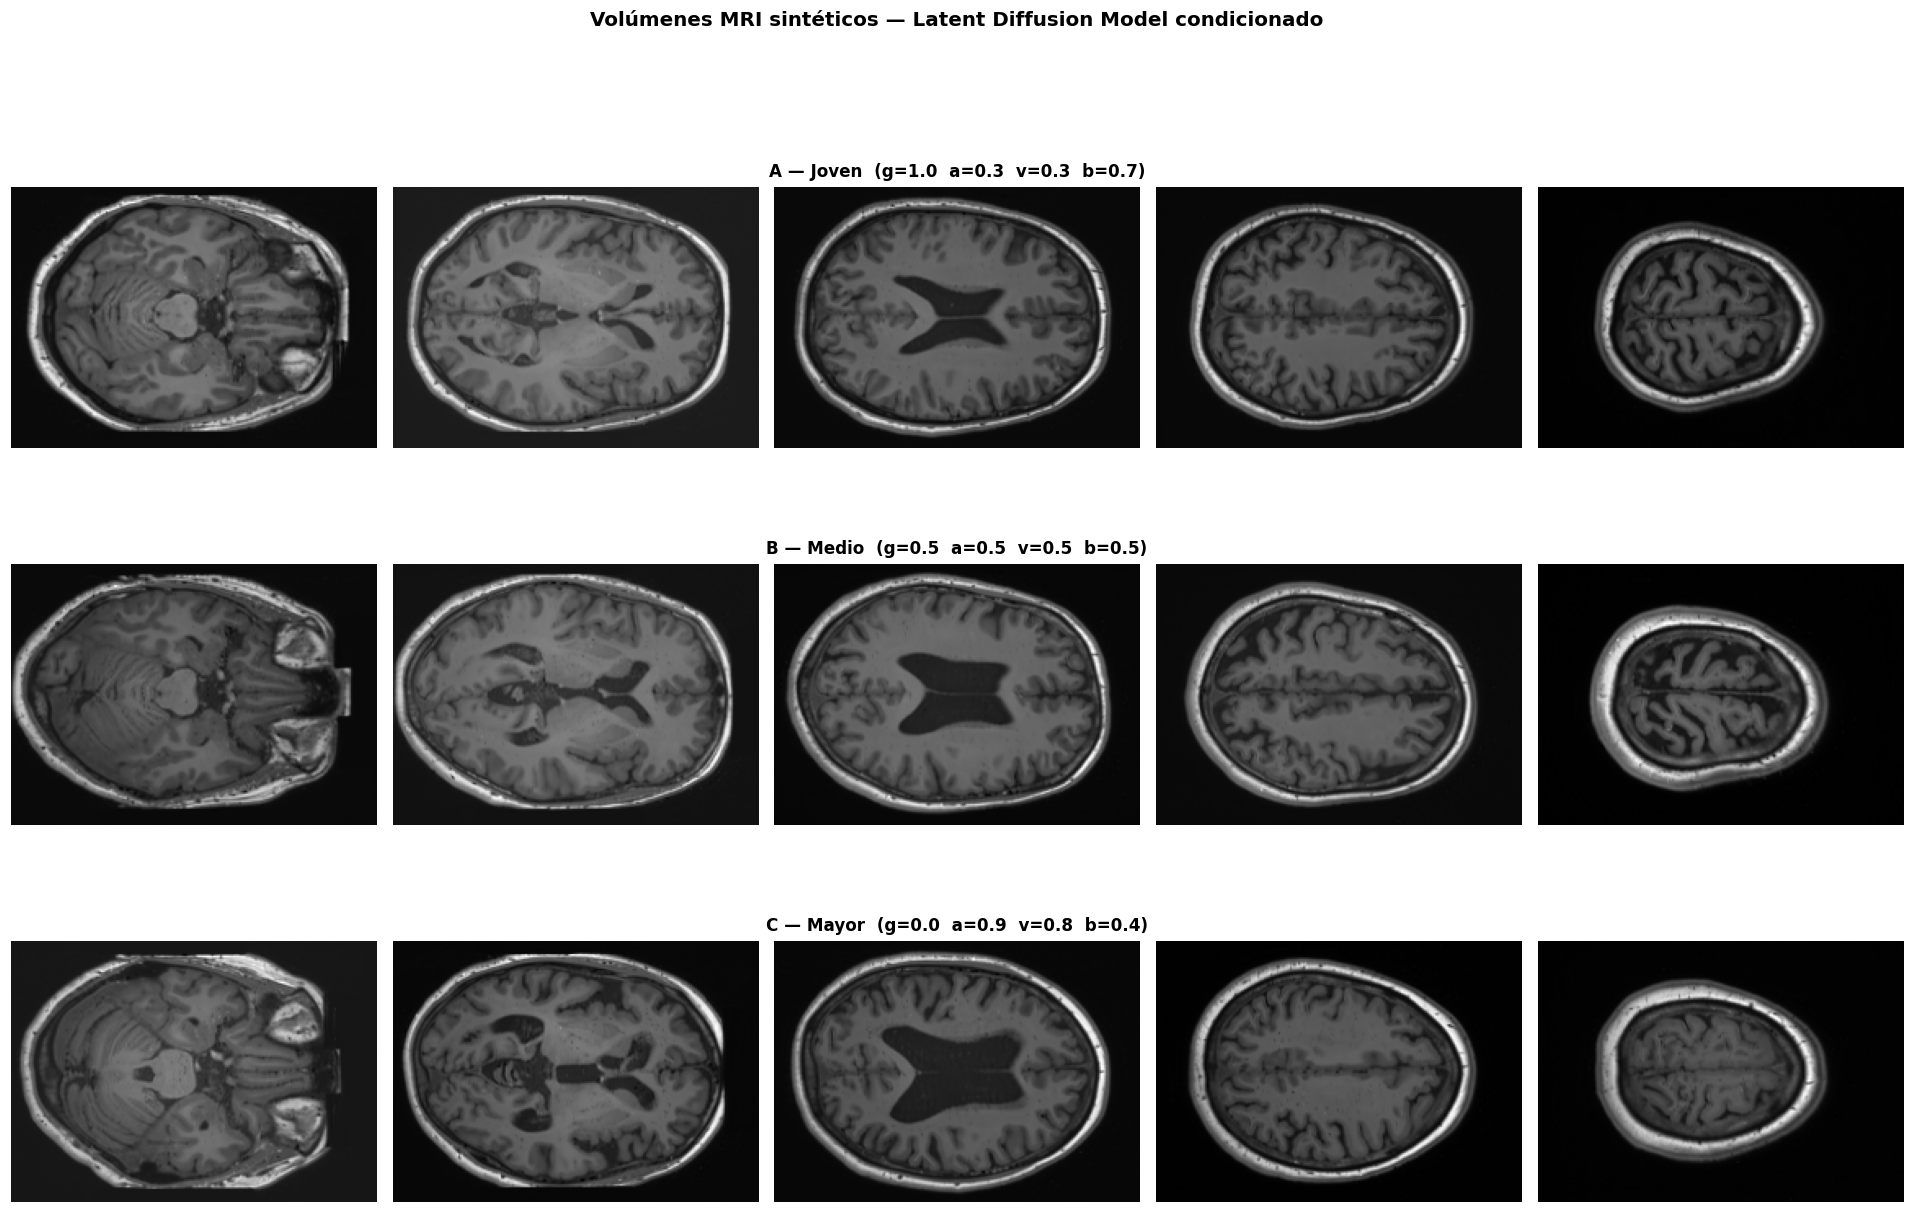


Resolución por volumen: (224, 160, 160) vóxeles (1 mm³ isotrópico)
Rango de intensidad: [-0.120, 1.076]


In [18]:
import nibabel as nib

OUTPUT_DIR = BUNDLE_DIR / "output"

# ── Recopilar los 3 volúmenes más recientes (última ejecución) ───────────────
N_CONFIGS = 3
all_nii = sorted(
    list(OUTPUT_DIR.rglob("*.nii")) + list(OUTPUT_DIR.rglob("*.nii.gz")),
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
nii_files = sorted(
    all_nii[:N_CONFIGS], key=lambda p: p.stat().st_mtime
)  # por orden de generación

print(
    f"Volúmenes en output: {len(all_nii)}  (mostrando los {len(nii_files)} más recientes)"
)
for f in nii_files:
    print(f"  - {f.name}")

if not nii_files:
    raise FileNotFoundError(
        f"No se han encontrado ficheros .nii/.nii.gz en {OUTPUT_DIR}"
    )

# ── Cargar volúmenes ────────────────────────────────────────────────────────
# Mapeo de parámetros a etiquetas de configuración
CONFIG_LABELS = {
    ("1.0", "0.3", "0.3", "0.7"): "A — Joven",
    ("0.5", "0.5", "0.5", "0.5"): "B — Medio",
    ("0.0", "0.9", "0.8", "0.4"): "C — Mayor",
}

volumes = []
labels = []

for nii_path in nii_files:
    vol = np.squeeze(nib.load(str(nii_path)).get_fdata())
    volumes.append(vol)
    parts = nii_path.stem.replace(".nii", "").split("_")
    if len(parts) >= 4:
        g, a, v, b = parts[-4], parts[-3], parts[-2], parts[-1]
        config_name = CONFIG_LABELS.get((g, a, v, b), "")
        if config_name:
            labels.append(f"{config_name}  (g={g}  a={a}  v={v}  b={b})")
        else:
            labels.append(f"g={g}  a={a}  v={v}  b={b}")
    else:
        labels.append(nii_path.stem)

# ── Visualización comparativa ───────────────────────────────────────────────
n_vols = len(volumes)
n_slices = 5
fig, axes = plt.subplots(n_vols, n_slices, figsize=(3.5 * n_slices, 4 * n_vols))
if n_vols == 1:
    axes = axes[np.newaxis, :]

for row, (vol, label) in enumerate(zip(volumes, labels)):
    # Eje 1 = superior-inferior (224 vóxeles) → cortes axiales
    z_indices = np.linspace(
        int(vol.shape[1] * 0.25), int(vol.shape[1] * 0.75), n_slices, dtype=int
    )
    for col, z in enumerate(z_indices):
        axes[row, col].imshow(np.rot90(vol[:, z, :]), cmap="gray")
        axes[row, col].axis("off")

fig.suptitle(
    "Volúmenes MRI sintéticos — Latent Diffusion Model condicionado",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout(rect=[0, 0, 1, 0.95], h_pad=4.0)

# Subtítulo centrado encima de cada fila
for row in range(n_vols):
    y_top = axes[row, 0].get_position().y1
    x_mid = (axes[row, 0].get_position().x0 + axes[row, -1].get_position().x1) / 2
    fig.text(
        x_mid,
        y_top + 0.005,
        labels[row],
        fontsize=11,
        fontweight="bold",
        ha="center",
        va="bottom",
    )

plt.show()

# ── Info técnica ────────────────────────────────────────────────────────────
ref = volumes[0]
print(f"\nResolución por volumen: {ref.shape} vóxeles (1 mm³ isotrópico)")
print(f"Rango de intensidad: [{ref.min():.3f}, {ref.max():.3f}]")

Observa las diferencias entre las tres generaciones:

- **Config A (joven)**: corteza cerebral gruesa, surcos poco prominentes y **ventrículos laterales pequeños**, consistente con un cerebro joven y sano.
- **Config B (medio)**: anatomía intermedia que sirve como referencia visual de control.
- **Config C (mayor)**: ventrículos laterales **visiblemente dilatados**, surcos más profundos y menor volumen cortical global — patrones típicos de **atrofia cerebral** asociada al envejecimiento.

El modelo ha aprendido estas relaciones a partir de los **31 740 volúmenes T1w del UK Biobank** con los que fue entrenado. La capacidad de control fino sobre las características demográficas y morfológicas es lo que distingue a los modelos de difusión condicionados de los generativos no condicionados (como un GAN estándar).

> **Para explorar más bundles**: visita el [MONAI Model Zoo](https://monai.io/model-zoo.html) o la [colección en HuggingFace](https://huggingface.co/MONAI). Encontrarás modelos para segmentación de órganos, detección de patologías, generación de imágenes en otras modalidades y muchos más, todos listos para descargar y usar con `monai.bundle`.

<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='vlm04'></a>

## <span style="color: #667eea;">Multimodalidad Imagen-Texto</span>

En la práctica clínica, las imágenes nunca viajan solas: van acompañadas de informes, historiales y anotaciones textuales. Los modelos **multimodales imagen-texto** aprovechan esta conexión natural para aprender representaciones que combinan lo visual y lo lingüístico.

¿Y si pudiéramos **preguntar** a un modelo qué ve en una imagen, o buscar imágenes similares describiendo en texto lo que buscamos? Hay dos grandes familias que lo hacen posible:

- **Modelos contrastivos** (ej. BiomedCLIP): alinean embeddings de imagen y texto para medir similitud — útiles para clasificación zero-shot y recuperación.
- **Modelos generativos** (ej. LLaVA-Med): integran un encoder visual con un LLM para producir descripciones en lenguaje natural a partir de la imagen.

A continuación veremos un ejemplo práctico de cada uno.


### *BiomedCLIP: encoder multimodal contrastivo*

[BiomedCLIP](https://huggingface.co/microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224) es una adaptación de CLIP al dominio biomédico, entrenado con **15 millones de pares imagen-texto** de artículos de PubMed. Su arquitectura combina un encoder visual (ViT-B/16) con un encoder textual (PubMedBERT) entrenados con **aprendizaje contrastivo**: las imágenes y los textos se proyectan al mismo espacio latente, donde podemos medir su similitud con un simple producto escalar.

Esto significa que BiomedCLIP no genera texto ni "razona" — simplemente responde a la pregunta: **¿cuál de estos textos describe mejor esta imagen?**

Cargamos BiomedCLIP a través de la librería `open_clip`, que da acceso directo al modelo alojado en HuggingFace. La función `create_model_from_pretrained` devuelve el modelo y el preprocesador de imagen; `get_tokenizer` nos da el tokenizador de texto.

In [19]:
import open_clip

biomedclip_model_id = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"

biomedclip_model, biomedclip_preprocess = open_clip.create_model_from_pretrained(
    biomedclip_model_id
)
biomedclip_tokenizer = open_clip.get_tokenizer(biomedclip_model_id)

biomedclip_model = biomedclip_model.to(device)
biomedclip_model.eval()

print("BiomedCLIP cargado correctamente.")

BiomedCLIP cargado correctamente.


### *Clasificación zero-shot con BiomedCLIP*

En clasificación **zero-shot** no entrenamos un clasificador: simplemente definimos las clases como descripciones en texto y dejamos que el modelo compare la imagen con cada una. La clase cuyo texto sea más similar al embedding de la imagen gana.

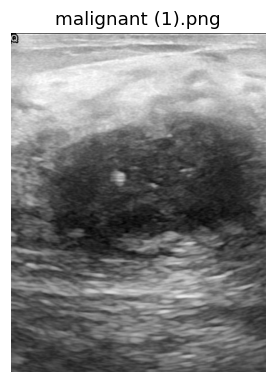

Probabilidades zero-shot:
  benign breast ultrasound    : 0.0329
  malignant breast ultrasound : 0.9671
Predicción: malignant breast ultrasound


In [20]:
labels = ["benign breast ultrasound", "malignant breast ultrasound"]
template = "this is a photo of "

candidates = [
    p
    for p in sorted((US_DATA_PATH / "malignant").glob("*.png"))
    if "_mask" not in p.name
]
if not candidates:
    raise RuntimeError(
        "No se encontraron imágenes de ejemplo en US_DATA_PATH/malignant"
    )

img_path = candidates[0]
img_pil = Image.open(img_path).convert("RGB")

img = biomedclip_preprocess(img_pil).unsqueeze(0).to(device)
txt = biomedclip_tokenizer([template + x for x in labels], context_length=256).to(
    device
)

with torch.no_grad():
    image_features, text_features, logit_scale = biomedclip_model(img, txt)
    probs = (logit_scale * image_features @ text_features.T).softmax(dim=-1).squeeze(0)

pred_idx = int(torch.argmax(probs).item())

plt.figure(figsize=(4, 4))
plt.imshow(img_pil)
plt.axis("off")
plt.title(img_path.name)
plt.show()

print("Probabilidades zero-shot:")
for i, lab in enumerate(labels):
    print(f"  {lab:28s}: {float(probs[i]):.4f}")
print(f"Predicción: {labels[pred_idx]}")

BiomedCLIP es especialmente útil para **ranking, recuperación y clasificación zero-shot** — no necesita datos etiquetados para clasificar. Pero su salida son **scores de similitud**, no explicaciones. ¿Y si quisiéramos que el modelo nos **describiera** lo que ve en la imagen?

### *LLaVA-Med: VLM generativo*

[LLaVA-Med](https://github.com/microsoft/LLaVA-Med) es un *Vision-Language Model* (VLM) que combina un encoder visual con un LLM (Mistral-7B) para generar texto libre condicionado por la imagen. A diferencia de BiomedCLIP, aquí le hacemos una **pregunta en lenguaje natural** y el modelo produce una **respuesta descriptiva**.

Cargamos LLaVA-Med desde HuggingFace con la librería `transformers`. El modelo ocupa ~14 GB en FP16, por lo que se carga con `device_map="auto"` para distribuir los pesos entre la GPU disponible y RAM. Si el entorno no tiene memoria suficiente, la carga fallará de forma controlada.

In [21]:
from transformers import AutoProcessor, LlavaForConditionalGeneration

llava_model_id = "chaoyinshe/llava-med-v1.5-mistral-7b-hf"
llava_processor = None
llava_model = None
llava_ready = False

try:
    print(f"Cargando {llava_model_id}...")
    llava_processor = AutoProcessor.from_pretrained(
        llava_model_id, trust_remote_code=True
    )
    llava_model = LlavaForConditionalGeneration.from_pretrained(
        llava_model_id,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        low_cpu_mem_usage=True,
        device_map="auto",
        trust_remote_code=True,
    )
    llava_model.eval()
    llava_ready = True
    print("LLaVA-Med cargado correctamente.")
except Exception as e:
    print("No se pudo cargar LLaVA-Med en este entorno.")
    print(f"Detalle: {e}")

Cargando chaoyinshe/llava-med-v1.5-mistral-7b-hf...


The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

LLaVA-Med cargado correctamente.


### *Descripción guiada con LLaVA-Med*

Ahora le pedimos al modelo que describa una ecografía mamaria en lenguaje natural. El diseño del **prompt** es importante: debe solicitar observaciones visuales concretas (forma, bordes, ecogenicidad) sin pedir un diagnóstico cerrado, ya que el modelo no ha sido validado clínicamente para uso diagnóstico.

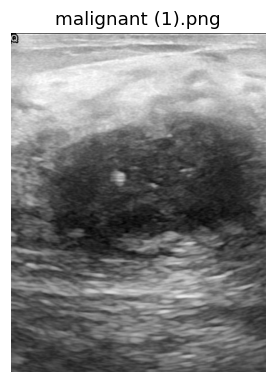


Respuesta del modelo:

The ultrasound image shows a possible lesion with a well-defined shape, clear borders, and a clear contrast. However, it is important to note that no definitive diagnosis can be made based on this image alone. Further evaluation and tests may be needed to determine the nature and cause of the lesion.


In [22]:
sample_imgs = [
    p
    for p in sorted((US_DATA_PATH / "malignant").glob("*.png"))
    if "_mask" not in p.name
]
if not sample_imgs:
    raise RuntimeError("No se encontraron imágenes en US_DATA_PATH/malignant")

img_path = sample_imgs[0]
image = Image.open(img_path).convert("RGB")

plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis("off")
plt.title(img_path.name)
plt.show()

if not llava_ready:
    print("Inferencia omitida porque LLaVA-Med no se pudo cargar.")
else:
    prompt = (
        "USER: <image>\n"
        "Describe brevemente los hallazgos visuales de esta ecografía mamaria. "
        "Comenta forma, bordes y contraste de la posible lesión, "
        "sin emitir diagnóstico definitivo.\n"
        "ASSISTANT:"
    )

    llava_device = next(llava_model.parameters()).device
    inputs = llava_processor(text=prompt, images=image, return_tensors="pt").to(
        llava_device
    )

    with torch.no_grad():
        output = llava_model.generate(
            **inputs,
            max_new_tokens=120,
            do_sample=False,
            use_cache=True,
            pad_token_id=llava_processor.tokenizer.eos_token_id,
        )

    response = llava_processor.batch_decode(output, skip_special_tokens=True)[0]
    response = response.split("ASSISTANT:")[-1].strip()

    print("\nRespuesta del modelo:\n")
    print(response)

La combinación de visión y lenguaje abre posibilidades que van más allá de la ecografía mamaria. Piensa en otros escenarios donde un modelo capaz de "leer" una imagen y generar texto podría ser útil:

- **Dermatoscopia**: describir patrones de pigmentación (retículo, glóbulos, velo azul-blanquecino) para triaje automatizado de lesiones cutáneas.
- **Radiología**: generar borradores de informes a partir de radiografías o CTs, que el radiólogo revisa y valida.
- **Patología digital**: resumir hallazgos histológicos en biopsias de alta resolución.
- **Formación**: crear herramientas educativas donde el alumno sube una imagen y recibe una descripción guiada de lo que debería observar.

Estos modelos no sustituyen al especialista, pero pueden actuar como **asistentes** que aceleran flujos de trabajo y democratizan el acceso a conocimiento visual especializado.

<div style="page-break-before: always;"></div>

<hr style="border: none; border-top: 2px solid #667eea; margin: 30px 0;">
<a class='anchor' id='ejercicios04'></a>

## <span style="color: #667eea;">Ejercicios Prácticos</span>

### *Ejercicio 1. Robustez del prompt en MedSAM*

Selecciona **10 imágenes con lesión** (5 benignas + 5 malignas) y, para cada una, calcula el **Dice** obtenido con prompt de **punto** y con prompt de **caja**. Presenta los resultados en un gráfico de barras agrupadas y calcula la media de Dice para cada tipo de prompt.

¿Cuál es más robusto? ¿Hay algún caso donde el punto supere a la caja? Comenta por qué.

<details>
<summary>💡 Pista</summary>
Reutiliza las funciones <code>segment_with_prompt</code>, <code>dice_score</code>, <code>prompt_point_from_mask</code> y <code>prompt_box_from_mask</code> ya definidas. Usa <code>plt.bar</code> con offset para barras agrupadas.
</details>

In [23]:
import gc
import torch


def release_gpu_memory(names_to_delete=None, verbose=True):
    if names_to_delete is None:
        names_to_delete = [
            "llava_model",
            "llava_processor",
            "biomedclip_model",
            "biomedclip_preprocess",
            "biomedclip_tokenizer",
            "demo",
        ]

    released = []
    for name in names_to_delete:
        if name in globals():
            del globals()[name]
            released.append(name)

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

        if verbose:
            alloc_gb = torch.cuda.memory_allocated() / (1024**3)
            reserved_gb = torch.cuda.memory_reserved() / (1024**3)
            print(f"Memoria CUDA asignada: {alloc_gb:.3f} GB")
            print(f"Memoria CUDA reservada: {reserved_gb:.3f} GB")

    if verbose and released:
        print("Objetos liberados:", ", ".join(released))
    elif verbose:
        print("No había objetos objetivo para liberar en globals().")


release_gpu_memory()
print(
    "Si vas a ejecutar MedSAM ahora, verifica que `model` y `processor` siguen cargados."
)

Memoria CUDA asignada: 0.396 GB
Memoria CUDA reservada: 5.227 GB
Objetos liberados: llava_model, llava_processor, biomedclip_model, biomedclip_preprocess, biomedclip_tokenizer, demo
Si vas a ejecutar MedSAM ahora, verifica que `model` y `processor` siguen cargados.


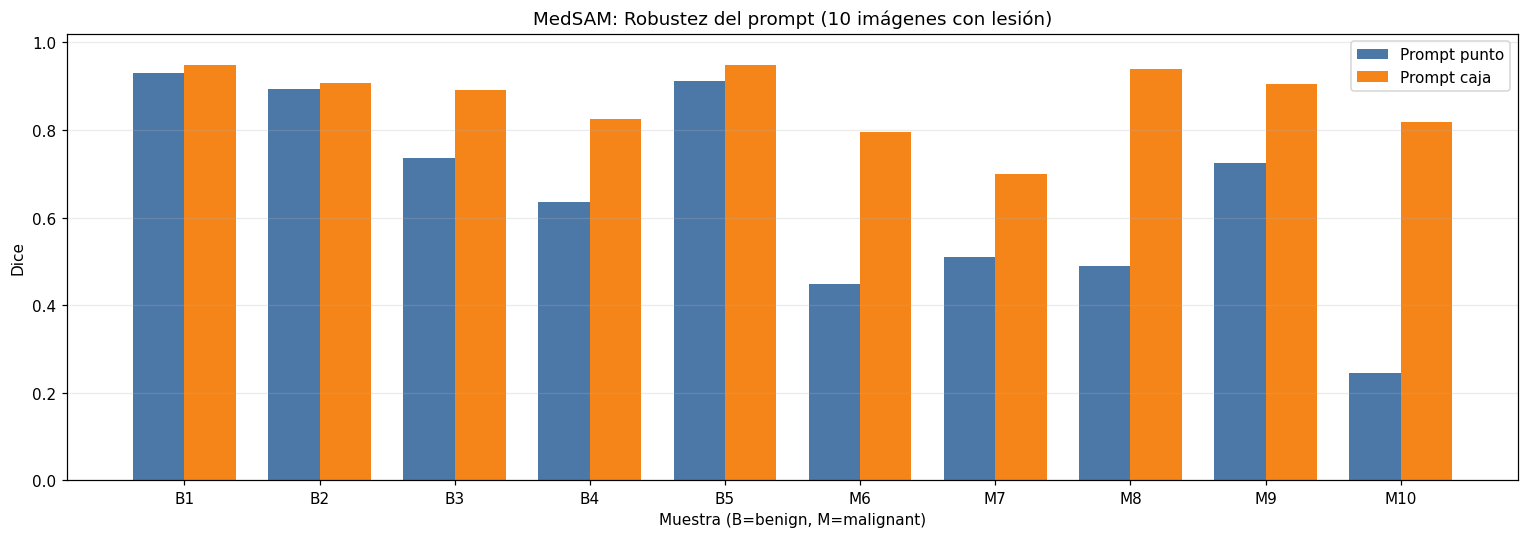

Resumen global
Media Dice punto: 0.652 | Desv. típica: 0.229
Media Dice caja:  0.868 | Desv. típica: 0.081
Victorias punto: 0  |  Victorias caja: 0  |  Empates: 0


,idx,class,image,dice_point,dice_box,delta_point_minus_box
0,1,benign,benign (157).png,0.930364,0.947639,-0.017275
1,2,benign,benign (46).png,0.893708,0.906469,-0.012760
2,3,benign,benign (391).png,0.736012,0.891778,-0.155766
3,4,benign,benign (150).png,0.635003,0.824869,-0.189866
4,5,benign,benign (280).png,0.911470,0.948949,-0.037479
5,6,malignant,malignant (147).png,0.447947,0.796097,-0.348151
6,7,malignant,malignant (51).png,0.510321,0.699547,-0.189226
7,8,malignant,malignant (180).png,0.489927,0.938546,-0.448619
8,9,malignant,malignant (131).png,0.724871,0.904537,-0.179666
9,10,malignant,malignant (116).png,0.243732,0.818730,-0.574998



No hubo casos donde el punto superara a la caja en esta muestra


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import random

# 1) Selección reproducible: 5 benignas + 5 malignas
rng = random.Random(GLOBAL_SEED)

benign_pool = [d for d in seg_data if "benign" in d["image"]]
malignant_pool = [d for d in seg_data if "malignant" in d["image"]]

if len(benign_pool) < 5 or len(malignant_pool) < 5:
    raise RuntimeError(
        "No hay suficientes imágenes para tomar 5 benignas y 5 malignas."
    )

benign_sel = rng.sample(benign_pool, 5)
malignant_sel = rng.sample(malignant_pool, 5)
eval_samples = benign_sel + malignant_sel

# 2) Evaluación Dice con prompt de punto y de caja
rows = []
for i, d in enumerate(eval_samples, start=1):
    img_pil = Image.open(d["image"]).convert("RGB")
    mask = (np.array(Image.open(d["mask"]).convert("L")) > 127).astype(np.uint8)

    pt = prompt_point_from_mask(mask)
    bx = prompt_box_from_mask(mask)

    if pt is None or bx is None:
        continue

    pred_pt = segment_with_prompt(model, processor, img_pil, "point", [pt], device)
    pred_bx = segment_with_prompt(model, processor, img_pil, "box", [bx], device)

    dice_pt = float(dice_score(pred_pt, mask))
    dice_bx = float(dice_score(pred_bx, mask))

    cls = Path(d["image"]).parent.name
    name = Path(d["image"]).name

    rows.append(
        {
            "idx": i,
            "class": cls,
            "image": name,
            "dice_point": dice_pt,
            "dice_box": dice_bx,
            "delta_point_minus_box": dice_pt - dice_bx,
        }
    )

df_eval = pd.DataFrame(rows)
if df_eval.empty:
    raise RuntimeError("No se pudo evaluar ninguna muestra.")

# 3) Gráfico de barras agrupadas
x = np.arange(len(df_eval))
w = 0.38

plt.figure(figsize=(14, 5))
plt.bar(
    x - w / 2, df_eval["dice_point"], width=w, label="Prompt punto", color="#4C78A8"
)
plt.bar(x + w / 2, df_eval["dice_box"], width=w, label="Prompt caja", color="#F58518")

labels = [f"{r['class'][0].upper()}{r['idx']}" for _, r in df_eval.iterrows()]
plt.xticks(x, labels, rotation=0)
plt.ylim(0, 1.02)
plt.ylabel("Dice")
plt.xlabel("Muestra (B=benign, M=malignant)")
plt.title("MedSAM: Robustez del prompt (10 imágenes con lesión)")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# 4) Métricas resumen
mean_pt = df_eval["dice_point"].mean()
mean_bx = df_eval["dice_box"].mean()
std_pt = df_eval["dice_point"].std()
std_bx = df_eval["dice_box"].std()

wins_pt = int((df_eval["dice_point"] > df_eval["dice_box"]).sum())
wins_bx = int((df_eval["dice_box"] > df_eval["dice_point"]).sum())
ties = int((np.isclose(df_eval["dice_point"], df_eval["dice_box"])).sum())

print("Resumen global")
print(f"Media Dice punto: {mean_pt:.3f} | Desv. típica: {std_pt:.3f}")
print(f"Media Dice caja:  {mean_bx:.3f} | Desv. típica: {std_bx:.3f}")
print(f"Victorias punto: {wins_pt}  |  Victorias caja: {wins_pt}  |  Empates: {ties}")

# 5) Tabla detallada
display(
    df_eval[
        ["idx", "class", "image", "dice_point", "dice_box", "delta_point_minus_box"]
    ]
)

# 6) Casos donde punto supera a caja
better_point = df_eval[df_eval["dice_point"] > df_eval["dice_box"]].copy()
if len(better_point) > 0:
    print("\nCasos donde el punto supera a la caja")
    display(
        better_point[
            ["idx", "class", "image", "dice_point", "dice_box", "delta_point_minus_box"]
        ]
    )
else:
    print("\nNo hubo casos donde el punto superara a la caja en esta muestra")

### *Ejercicio 2. Radiómica con segmentación automática vs. manual*

En la sección de radiómica hemos extraído features usando las **máscaras manuales** del dataset. Pero en un escenario real, las máscaras serían generadas por un modelo de segmentación (como DynUNet).

Selecciona **10 imágenes con lesión** (5 benignas + 5 malignas) y, para cada una, extrae los features radiómicos usando **dos máscaras**: la ground truth manual y la predicción de DynUNet. Entrena un clasificador L1 con cada conjunto de features y compara el **AUC** obtenido.

¿Cuánto afecta la calidad de la segmentación al rendimiento del clasificador? ¿Los features más importantes coinciden entre la versión con máscara manual y la versión con máscara automática?

<details>
<summary>💡 Pista</summary>
Reutiliza el pipeline de segmentación DynUNet para obtener las predicciones. Usa el mismo extractor <code>RadiomicsFeatureExtractor</code> cambiando la máscara de entrada. Compara los AUC con <code>cross_val_score</code>.
</details>

INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.featureextractor:Computing shape2D
INFO:radiomics.featureextractor:Adding image type "Original" with custom settings: {}
INFO:radiomics.featureextractor:Calculating features for original image
INFO:radiomics.featureextractor:Computing firstorder
INFO:radiomics.featureextractor:Computing glcm
INFO:radiomics.featureextractor:Calculating features with label: 1
INFO:radiomics.featureextractor:Loading image and mask
INFO:radiomics.fea

Resultados clasificación (L1 Logistic Regression)
Muestras usadas: 10
Features comunes: 51

Manual (GT):   AUC = 0.400 ± 0.490
Automática:    AUC = 1.000 ± 0.000
Diferencia (Auto - Manual): +0.600

Dice DynUNet vs GT en estos casos: 0.687 ± 0.238

Top features (Manual):
 1. original_shape2D_MinorAxisLength

Top features (Automática):
 1. original_glcm_MCC
 2. original_firstorder_10Percentile
 3. original_firstorder_MeanAbsoluteDeviation

Coincidencias en top features:
Ninguna coincidencia en el top-10.


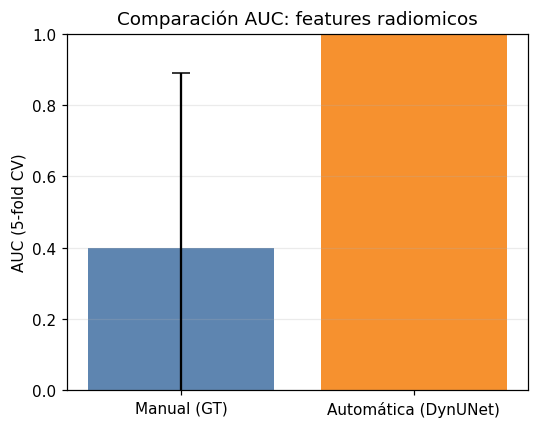

,sample_id,class,file,dice_dynunet_vs_gt
0,1,benign,benign (157).png,0.914262
1,2,benign,benign (46).png,0.911635
2,3,benign,benign (391).png,0.475611
3,4,benign,benign (150).png,0.717252
4,5,benign,benign (280).png,0.924500
5,6,malignant,malignant (147).png,0.470811
6,7,malignant,malignant (51).png,0.776302
7,8,malignant,malignant (180).png,0.529573
8,9,malignant,malignant (131).png,0.889523
9,10,malignant,malignant (116).png,0.257297


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
import SimpleITK as sitk
from PIL import Image
from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# =========================================================
# 1) Selección de 10 casos (5 benign + 5 malignant)
# =========================================================
rng = random.Random(GLOBAL_SEED)

benign_pool = [d for d in seg_data if "benign" in d["image"]]
malignant_pool = [d for d in seg_data if "malignant" in d["image"]]

if len(benign_pool) < 5 or len(malignant_pool) < 5:
    raise RuntimeError("No hay suficientes imágenes con lesión para seleccionar 5+5.")

selected = rng.sample(benign_pool, 5) + rng.sample(malignant_pool, 5)


# =========================================================
# 2) Helpers: predicción DynUNet y extracción radiómica
# =========================================================
def predict_dynunet_mask_from_gray(img_gray, model, device, img_size=128, thr=0.5):
    # Preprocesado similar al entrenamiento (resize + normalización)
    orig_h, orig_w = img_gray.shape
    img_r = cv2.resize(
        img_gray, (img_size, img_size), interpolation=cv2.INTER_LINEAR
    ).astype(np.float32)

    # ScaleIntensity + NormalizeIntensity (aprox)
    mn, mx = img_r.min(), img_r.max()
    img_r = (img_r - mn) / (mx - mn + 1e-8)
    img_r = (img_r - img_r.mean()) / (img_r.std() + 1e-8)

    x = torch.from_numpy(img_r).unsqueeze(0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        p = torch.sigmoid(model(x)).squeeze().cpu().numpy()

    p_bin = (p > thr).astype(np.uint8)
    p_up = cv2.resize(p_bin, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST).astype(
        np.uint8
    )
    return p_up


def radiomics_from_arrays(img_gray, mask_bin, extractor, min_pixels=10):
    mask_bin = (mask_bin > 0).astype(np.uint8)
    if mask_bin.sum() < min_pixels:
        return None
    img_sitk = sitk.GetImageFromArray(img_gray.astype(np.float64))
    mask_sitk = sitk.GetImageFromArray(mask_bin.astype(np.uint8))
    try:
        out = extractor.execute(img_sitk, mask_sitk)
        feats = {k: float(v) for k, v in out.items() if not k.startswith("diagnostics")}
        return feats
    except Exception:
        return None


def evaluate_l1_auc(df_feats, label_col="class", id_cols=("sample_id", "file")):
    feat_cols_local = [c for c in df_feats.columns if c not in [label_col, *id_cols]]
    X = df_feats[feat_cols_local].fillna(0).values
    y = (df_feats[label_col] == "malignant").astype(int).values

    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    penalty="l1",
                    solver="saga",
                    C=0.5,
                    max_iter=6000,
                    random_state=GLOBAL_SEED,
                ),
            ),
        ]
    )

    auc_scores = cross_val_score(pipe, X, y, cv=5, scoring="roc_auc")
    pipe.fit(X, y)

    coefs = np.abs(pipe["clf"].coef_[0])
    top_idx = np.argsort(coefs)[::-1]
    top_feats = [feat_cols_local[i] for i in top_idx if coefs[i] > 0][:10]

    return {
        "auc_mean": float(auc_scores.mean()),
        "auc_std": float(auc_scores.std()),
        "top_features": top_feats,
        "n_features": len(feat_cols_local),
        "n_samples": len(df_feats),
    }


# =========================================================
# 3) Construcción de features manuales vs automáticos
# =========================================================
rows_manual, rows_auto, rows_quality = [], [], []

for i, d in enumerate(selected, start=1):
    cls = Path(d["image"]).parent.name
    fname = Path(d["image"]).name

    img_gray = np.array(Image.open(d["image"]).convert("L"), dtype=np.float32)
    gt_mask = (np.array(Image.open(d["mask"]).convert("L")) > 127).astype(np.uint8)

    pred_mask = predict_dynunet_mask_from_gray(
        img_gray, dynunet_model, device, img_size=SEG_IMG_SIZE, thr=0.5
    )

    dice_auto = float(dice_score(pred_mask, gt_mask))
    rows_quality.append(
        {"sample_id": i, "class": cls, "file": fname, "dice_dynunet_vs_gt": dice_auto}
    )

    feats_manual = radiomics_from_arrays(img_gray, gt_mask, extractor)
    feats_auto = radiomics_from_arrays(img_gray, pred_mask, extractor)

    # Para comparar justo, conservamos solo casos con ambos conjuntos válidos
    if feats_manual is None or feats_auto is None:
        continue

    feats_manual.update({"sample_id": i, "class": cls, "file": fname})
    feats_auto.update({"sample_id": i, "class": cls, "file": fname})

    rows_manual.append(feats_manual)
    rows_auto.append(feats_auto)

df_manual = pd.DataFrame(rows_manual)
df_auto = pd.DataFrame(rows_auto)
df_quality = pd.DataFrame(rows_quality)

if len(df_manual) < 10 or len(df_auto) < 10:
    print(
        f"Aviso: se han usado {len(df_manual)} casos válidos (de 10) para la comparación radiomica."
    )

# Asegurar mismas muestras y mismo espacio de features
common_ids = sorted(set(df_manual["sample_id"]).intersection(set(df_auto["sample_id"])))
df_manual = (
    df_manual[df_manual["sample_id"].isin(common_ids)].copy().sort_values("sample_id")
)
df_auto = df_auto[df_auto["sample_id"].isin(common_ids)].copy().sort_values("sample_id")

if len(common_ids) < 6:
    raise RuntimeError(
        "Muy pocos casos válidos tras extracción radiomica para evaluar AUC de forma estable."
    )

# Igualar columnas de features
meta_cols = ["sample_id", "class", "file"]
f_manual = [c for c in df_manual.columns if c not in meta_cols]
f_auto = [c for c in df_auto.columns if c not in meta_cols]
common_feats = sorted(set(f_manual).intersection(set(f_auto)))

df_manual = df_manual[meta_cols + common_feats].copy()
df_auto = df_auto[meta_cols + common_feats].copy()

# =========================================================
# 4) Clasificación L1 y comparación AUC
# =========================================================
res_manual = evaluate_l1_auc(df_manual)
res_auto = evaluate_l1_auc(df_auto)

print("Resultados clasificación (L1 Logistic Regression)")
print(f"Muestras usadas: {res_manual['n_samples']}")
print(f"Features comunes: {res_manual['n_features']}")
print()
print(
    f"Manual (GT):   AUC = {res_manual['auc_mean']:.3f} ± {res_manual['auc_std']:.3f}"
)
print(f"Automática:    AUC = {res_auto['auc_mean']:.3f} ± {res_auto['auc_std']:.3f}")
print(
    f"Diferencia (Auto - Manual): {res_auto['auc_mean'] - res_manual['auc_mean']:+.3f}"
)

# Calidad media de segmentación automática en los casos usados
mean_dice = df_quality[df_quality["sample_id"].isin(common_ids)][
    "dice_dynunet_vs_gt"
].mean()
std_dice = df_quality[df_quality["sample_id"].isin(common_ids)][
    "dice_dynunet_vs_gt"
].std(ddof=1)
print()
print(f"Dice DynUNet vs GT en estos casos: {mean_dice:.3f} ± {std_dice:.3f}")

# =========================================================
# 5) Top features y solapamiento
# =========================================================
top_m = res_manual["top_features"]
top_a = res_auto["top_features"]
overlap = [f for f in top_m if f in set(top_a)]

print("\nTop features (Manual):")
for k, f in enumerate(top_m, start=1):
    print(f"{k:2d}. {f}")

print("\nTop features (Automática):")
for k, f in enumerate(top_a, start=1):
    print(f"{k:2d}. {f}")

print("\nCoincidencias en top features:")
if len(overlap) == 0:
    print("Ninguna coincidencia en el top-10.")
else:
    for f in overlap:
        print(f"- {f}")

# =========================================================
# 6) Visuales rápidos
# =========================================================
plt.figure(figsize=(5, 4))
means = [res_manual["auc_mean"], res_auto["auc_mean"]]
stds = [res_manual["auc_std"], res_auto["auc_std"]]
labels = ["Manual (GT)", "Automática (DynUNet)"]

plt.bar(labels, means, yerr=stds, color=["#4C78A8", "#F58518"], alpha=0.9, capsize=6)
plt.ylim(0, 1.0)
plt.ylabel("AUC (5-fold CV)")
plt.title("Comparación AUC: features radiomicos")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# Tabla por caso
df_case = (
    df_quality[df_quality["sample_id"].isin(common_ids)].copy().sort_values("sample_id")
)
display(df_case)

### *Ejercicio 3. Exploración de MONAI Bundles en HuggingFace*

En la sección de modelos generativos hemos utilizado el bundle `brain_image_synthesis_latent_diffusion_model`. La [colección MONAI en HuggingFace](https://huggingface.co/MONAI) contiene decenas de bundles para distintas tareas clínicas y modalidades de imagen.

**Parte A — Búsqueda.** Accede a [huggingface.co/MONAI](https://huggingface.co/MONAI) y localiza **dos bundles** que te resulten interesantes (distintos del que ya hemos usado). Para cada uno, indica:

1. Nombre del bundle.
2. Tarea que resuelve (segmentación, clasificación, generación, detección…).
3. Modalidad de imagen (CT, MRI, ecografía, rayos X, patología…).
4. Dataset con el que fue entrenado.
5. Una aplicación clínica concreta donde podría utilizarse.

**Parte B — Descarga y exploración.** Elige uno de los dos bundles anteriores y descárgalo con `snapshot_download`. Explora su contenido (archivos de configuración, pesos, README) y describe su estructura. Si el bundle incluye un script de inferencia, intenta ejecutarlo sobre un ejemplo y muestra el resultado.

<details>
<summary>💡 Pista</summary>
Usa <code>snapshot_download(repo_id="MONAI/nombre_del_bundle", local_dir="...")</code> para descargar. Inspecciona el README.md del bundle — ahí se documenta la arquitectura, el dataset, las métricas y los comandos de inferencia disponibles.
</details>

Descargando bundle: MONAI/spleen_ct_segmentation


/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

[OK] Bundle descargado en: /home/pyros05/Escritorio/cid-upct/Prácticas/4º Curso/PIM/Sesión 4/kaggle/working/spleen_ct_segmentation

Estructura principal:
 - .cache
 - .gitattributes
 - LICENSE
 - Task09_Spleen
 - configs
 - docs
 - eval
 - models

Models:
 - model.pt (18.4 MB)
 - model.ts (18.5 MB)

Primeras líneas del README
# Model Overview
A pre-trained model for volumetric (3D) segmentation of the spleen from CT images.

This model is trained using the runner-up [1] awarded pipeline of the "Medical Segmentation Decathlon Challenge 2018" using the UNet architecture [2] with 32 training images and 9 validation images.

![model workflow](https://developer.download.nvidia.com/assets/Clara/Images/clara_pt_spleen_ct_segmentation_workflow.png)

## Data
The training dataset is the Spleen Task from the Medical Segmentation Decathalon. Users can find more details on the datasets at http://medicaldecathlon.com/.

- Target: Spleen
- Modality: CT
- Size: 61 3D volumes (41 Training + 20 Testing)

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


2026-03-24 17:24:49,141 - INFO - Setting logging properties based on config: /home/pyros05/Escritorio/cid-upct/Prácticas/4º Curso/PIM/Sesión 4/kaggle/working/spleen_ct_segmentation/configs/logging.conf.


/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
  warn_deprecated(argname, msg, warning_category)


2026-03-24 17:24:49,426 - root - INFO - Restored all variables from ./models/model.pt
2026-03-24 17:24:49,427 - INFO - --- input summary of monai.bundle.scripts.run ---
2026-03-24 17:24:49,427 - INFO - > dataset_dir: ('/home/pyros05/Escritorio/cid-upct/Prácticas/4º Curso/PIM/Sesión '
 '4/kaggle/working/spleen_ct_segmentation/Task09_Spleen')
2026-03-24 17:24:49,427 - INFO - ---


2026-03-24 17:24:49,428 - ignite.engine.engine.SupervisedEvaluator - INFO - Engine run resuming from iteration 0, epoch 0 until 1 epochs


/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.

2026-03-24 17:24:53,315 INFO image_writer.py:197 - writing: eval/spleen_1/spleen_1_trans.nii.gz
2026-03-24 17:25:08,012 INFO image_writer.py:197 - writing: eval/spleen_11/spleen_11_trans.nii.gz
2026-03-24 17:25:13,936 INFO image_writer.py:197 - writing: eval/spleen_15/spleen_15_trans.nii.gz
2026-03-24 17:25:28,779 INFO image_writer.py:197 - writing: eval/spleen_23/spleen_23_trans.nii.gz
2026-03-24 17:25:47,838 INFO image_writer.py:197 - writing: eval/spleen_30/spleen_30_trans.nii.gz
2026-03-24 17:25:55,221 INFO image_writer.py:197 - writing: eval/spleen_34/spleen_34_trans.nii.gz
2026-03-24 17:26:04,402 INFO image_writer.py:197 - writing: eval/spleen_35/spleen_35_trans.nii.gz
2026-03-24 17:26:30,004 INFO image_writer.py:197 - writing: eval/spleen_36/spleen_36_trans.nii.gz
2026-03-24 17:27:08,650 INFO image_writer.py:197 - writing: eval/spleen_37/spleen_37_trans.nii.gz
2026-03-24 17:27:26,844 INFO image_writer.py:197 - writing: eval/spleen_39/spleen_39_trans.nii.gz
2026-03-24 17:27:41,44

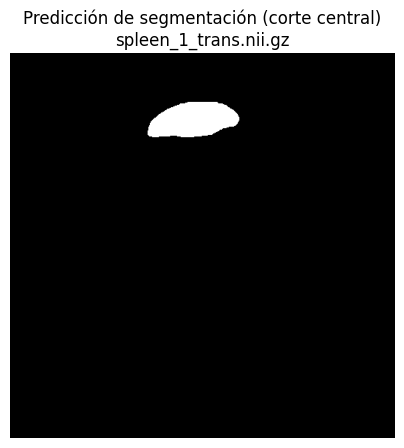

In [1]:
import os
import json
import subprocess
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from huggingface_hub import snapshot_download

# =========================================================
# 0) Dependencia opcional necesaria para monai.bundle run
# =========================================================
try:
    import ignite
except ImportError:
    print("[!] Instalando pytorch-ignite...")
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", "pytorch-ignite"]
    )
    import ignite  # noqa: F401

# =========================================================
# 1) Descargar bundle
# =========================================================
KAGGLE_ROOT = (
    Path("/kaggle") if "KAGGLE_KERNEL_RUN_TYPE" in os.environ else Path("./kaggle")
)
BUNDLE_ID = "MONAI/spleen_ct_segmentation"
BUNDLE_DIR = (KAGGLE_ROOT / "working" / "spleen_ct_segmentation").resolve()

BUNDLE_DIR.mkdir(parents=True, exist_ok=True)

print(f"Descargando bundle: {BUNDLE_ID}")
snapshot_download(
    repo_id=BUNDLE_ID, local_dir=str(BUNDLE_DIR), local_dir_use_symlinks=False
)
print(f"[OK] Bundle descargado en: {BUNDLE_DIR}")

# =========================================================
# 2) Explorar estructura
# =========================================================
print("\nEstructura principal:")
for p in sorted(BUNDLE_DIR.iterdir()):
    print(" -", p.name)

print("\nModels:")
for p in sorted((BUNDLE_DIR / "models").glob("*")):
    print(" -", p.name, f"({p.stat().st_size / 1024 / 1024:.1f} MB)")

readme_path = BUNDLE_DIR / "docs" / "README.md"
if readme_path.exists():
    print("\nPrimeras líneas del README")
    txt = readme_path.read_text(encoding="utf-8", errors="ignore").splitlines()
    for line in txt[:40]:
        print(line)

# =========================================================
# 3) Buscar dataset spleen para inferencia (imagesTs)
# =========================================================
SPLEEN_DATASET_DIR = None

candidate_roots = [
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("./kaggle/input"),
    Path("."),
]

for root in candidate_roots:
    root = root.resolve()
    if not root.exists():
        continue
    matches = list(root.rglob("imagesTs"))
    for m in matches:
        nii = [p for p in m.glob("*.nii.gz") if not p.name.startswith("._")]
        if len(nii) > 0:
            SPLEEN_DATASET_DIR = m.parent.resolve()
            break
    if SPLEEN_DATASET_DIR is not None:
        break

print(
    "\nDataset detectado:",
    SPLEEN_DATASET_DIR if SPLEEN_DATASET_DIR is not None else "NO",
)

# =========================================================
# 4) Inferencia MONAI Bundle (modo robusto sin OOM en GPU)
# =========================================================
EVAL_DIR = BUNDLE_DIR / "eval"
SAFE_CONFIG = BUNDLE_DIR / "configs" / "inference_safe_cpu.json"
BASE_CONFIG = BUNDLE_DIR / "configs" / "inference.json"

if SPLEEN_DATASET_DIR is None:
    print("\nNo se encontró Task09_Spleen con imagesTs.")
    print("Para ejecutar inferencia, añade el dataset y vuelve a correr esta celda.")
    print("Comando esperado:")
    print(
        "python -m monai.bundle run --config_file configs/inference.json --dataset_dir <Task09_Spleen>"
    )
else:
    test_files = sorted(
        [
            p
            for p in (SPLEEN_DATASET_DIR / "imagesTs").glob("*.nii.gz")
            if not p.name.startswith("._")
        ]
    )
    print(f"\nVolúmenes de test detectados para inferencia: {len(test_files)}")
    if len(test_files) == 0:
        raise RuntimeError(
            f"No hay .nii.gz válidos en {(SPLEEN_DATASET_DIR / 'imagesTs')}"
        )

    # Generar una config segura: todo en CPU + menor presión de memoria
    cfg = json.loads(BASE_CONFIG.read_text(encoding="utf-8"))
    cfg["device"] = "$torch.device('cpu')"
    cfg["network"] = "$@network_def.to(@device)"
    cfg["dataloader"]["num_workers"] = 0
    cfg["inferer"]["sw_batch_size"] = 1
    cfg["evaluator"]["amp"] = False
    cfg["evaluator"]["device"] = "@device"
    SAFE_CONFIG.write_text(json.dumps(cfg, indent=4), encoding="utf-8")
    print(f"[OK] Config segura creada: {SAFE_CONFIG.name}")

    print("Ejecutando inferencia (CPU-safe)...")
    cmd = [
        sys.executable,
        "-m",
        "monai.bundle",
        "run",
        "--config_file",
        str(SAFE_CONFIG),
        "--dataset_dir",
        str(SPLEEN_DATASET_DIR.resolve()),
    ]
    print(" ".join(cmd))
    subprocess.check_call(cmd, cwd=str(BUNDLE_DIR))
    print("[OK] Inferencia completada.")

    pred_files = sorted(list(EVAL_DIR.rglob("*.nii.gz")))
    print(f"Máscaras generadas: {len(pred_files)}")
    for f in pred_files[:5]:
        print(" -", f)

    if len(pred_files) == 0:
        print(
            "[WARN] No se encontraron salidas en eval/. Revisa la traza de monai.bundle."
        )

    # =========================================================
    # 5) Mostrar resultado (una predicción)
    # =========================================================
    if len(pred_files) > 0:
        pred_path = pred_files[0]
        pred = np.squeeze(nib.load(str(pred_path)).get_fdata())

        # Coger corte central
        if pred.ndim == 3:
            z = pred.shape[2] // 2
            sl = pred[:, :, z]
        else:
            sl = pred

        plt.figure(figsize=(5, 5))
        plt.imshow(sl, cmap="gray")
        plt.title(f"Predicción de segmentación (corte central)\n{pred_path.name}")
        plt.axis("off")
        plt.show()

### *Ejercicio 4. Impacto del prompt textual en BiomedCLIP*

BiomedCLIP depende del **texto usado como prompt**. Repite la clasificación zero-shot sobre 10 imágenes (benignas y malignas) cambiando las descripciones textuales. Compara:
- Versión genérica: `"benign breast ultrasound"`, `"malignant breast ultrasound"`
- Versión detallada: `"a breast ultrasound showing a well-defined hypoechoic benign mass"`, `"a breast ultrasound showing an irregular hypoechoic malignant mass with posterior shadowing"`

¿Cambian las predicciones? ¿Los prompts más específicos mejoran la clasificación? Justifica.

<details>
<summary>💡 Pista</summary>
Reutiliza el código de la celda de clasificación zero-shot (BiomedCLIP) con dos diccionarios de prompts diferentes. Compara las probabilidades predichas y el accuracy sobre las mismas imágenes.
</details>

[INFO] BiomedCLIP no estaba en memoria; recargando modelo...
[OK] BiomedCLIP recargado.
=== Accuracy ===
Generic : 0.500 (5/10)
Detailed: 0.600 (6/10)
Cambios de predicción entre prompts: 1/10

=== Casos que cambian de clase predicha ===


,file,true_label,pred_label_generic,pred_label_detailed,p_malign_generic,p_malign_detailed
1,benign (11).png,benign,malignant,benign,0.922866,0.451264



=== Reporte Generic ===
              precision    recall  f1-score   support

      benign      0.000     0.000     0.000         5
   malignant      0.500     1.000     0.667         5

    accuracy                          0.500        10
   macro avg      0.250     0.500     0.333        10
weighted avg      0.250     0.500     0.333        10

=== Reporte Detailed ===
              precision    recall  f1-score   support

      benign      1.000     0.200     0.333         5
   malignant      0.556     1.000     0.714         5

    accuracy                          0.600        10
   macro avg      0.778     0.600     0.524        10
weighted avg      0.778     0.600     0.524        10



/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/pyros05/anaconda3/envs/pim/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

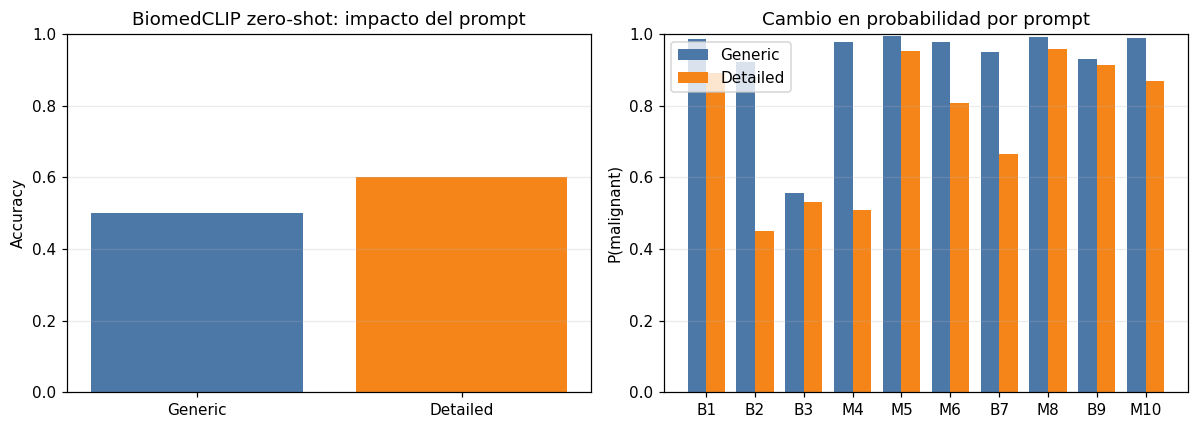

,file,true_label,pred_label_generic,p_benign_generic,p_malign_generic,pred_label_detailed,p_benign_detailed,p_malign_detailed
0,benign (47).png,benign,malignant,0.013784,0.986216,malignant,0.107396,0.892604
1,benign (11).png,benign,malignant,0.077134,0.922866,benign,0.548736,0.451264
2,benign (225).png,benign,malignant,0.443196,0.556804,malignant,0.467457,0.532543
3,malignant (122).png,malignant,malignant,0.020915,0.979085,malignant,0.491461,0.508539
4,malignant (155).png,malignant,malignant,0.004460,0.995540,malignant,0.046010,0.953990
5,malignant (130).png,malignant,malignant,0.022706,0.977294,malignant,0.193123,0.806877
6,benign (394).png,benign,malignant,0.050095,0.949905,malignant,0.334471,0.665529
7,malignant (150).png,malignant,malignant,0.009043,0.990957,malignant,0.040692,0.959308
8,benign (150).png,benign,malignant,0.068235,0.931765,malignant,0.086069,0.913931
9,malignant (8).png,malignant,malignant,0.011349,0.988651,malignant,0.130795,0.869205


In [28]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import classification_report
import torch
import open_clip

# =========================================================
# 0) Asegurar BiomedCLIP cargado (por si se liberó memoria antes)
# =========================================================
required_objs = ["biomedclip_model", "biomedclip_preprocess", "biomedclip_tokenizer"]
if not all(name in globals() for name in required_objs):
    print("[INFO] BiomedCLIP no estaba en memoria; recargando modelo...")
    biomedclip_model_id = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
    biomedclip_model, biomedclip_preprocess = open_clip.create_model_from_pretrained(
        biomedclip_model_id
    )
    biomedclip_tokenizer = open_clip.get_tokenizer(biomedclip_model_id)
    biomedclip_model = biomedclip_model.to(device)
    biomedclip_model.eval()
    print("[OK] BiomedCLIP recargado.")

# =========================================================
# 1) Selección de 10 imágenes (5 benign + 5 malignant)
# =========================================================
rng = random.Random(GLOBAL_SEED)

benign_imgs = [
    p for p in sorted((US_DATA_PATH / "benign").glob("*.png")) if "_mask" not in p.name
]
malig_imgs = [
    p
    for p in sorted((US_DATA_PATH / "malignant").glob("*.png"))
    if "_mask" not in p.name
]

if len(benign_imgs) < 5 or len(malig_imgs) < 5:
    raise RuntimeError(
        "No hay suficientes imágenes para seleccionar 5 benign y 5 malignant."
    )

sel_benign = rng.sample(benign_imgs, 5)
sel_malig = rng.sample(malig_imgs, 5)

samples = [(p, 0, "benign") for p in sel_benign] + [
    (p, 1, "malignant") for p in sel_malig
]
rng.shuffle(samples)

# =========================================================
# 2) Prompts a comparar
# =========================================================
prompt_sets = {
    "generic": [
        "benign breast ultrasound",
        "malignant breast ultrasound",
    ],
    "detailed": [
        "a breast ultrasound showing a well-defined hypoechoic benign mass",
        "a breast ultrasound showing an irregular hypoechoic malignant mass with posterior shadowing",
    ],
}
class_names = ["benign", "malignant"]  # índice 0 y 1


# =========================================================
# 3) Función de inferencia zero-shot con BiomedCLIP
# =========================================================
def biomedclip_predict_proba(img_pil, texts):
    img_t = biomedclip_preprocess(img_pil).unsqueeze(0).to(device)
    txt_t = biomedclip_tokenizer(texts, context_length=256).to(device)
    with torch.no_grad():
        image_features, text_features, logit_scale = biomedclip_model(img_t, txt_t)
        probs = (
            (logit_scale * image_features @ text_features.T).softmax(dim=-1).squeeze(0)
        )
    return probs.detach().cpu().numpy()  # shape (2,)


# =========================================================
# 4) Evaluación en ambos sets de prompts
# =========================================================
rows = []
for img_path, y_true, y_true_name in samples:
    img_pil = Image.open(img_path).convert("RGB")
    row = {
        "file": img_path.name,
        "true_idx": y_true,
        "true_label": y_true_name,
    }

    for mode in ["generic", "detailed"]:
        probs = biomedclip_predict_proba(img_pil, prompt_sets[mode])
        pred_idx = int(np.argmax(probs))
        row[f"p_benign_{mode}"] = float(probs[0])
        row[f"p_malign_{mode}"] = float(probs[1])
        row[f"pred_idx_{mode}"] = pred_idx
        row[f"pred_label_{mode}"] = class_names[pred_idx]

    rows.append(row)

df_eval = pd.DataFrame(rows)

# =========================================================
# 5) Métricas comparativas
# =========================================================
acc_generic = (df_eval["pred_idx_generic"] == df_eval["true_idx"]).mean()
acc_detailed = (df_eval["pred_idx_detailed"] == df_eval["true_idx"]).mean()

changed = (df_eval["pred_idx_generic"] != df_eval["pred_idx_detailed"]).sum()
n = len(df_eval)

print("=== Accuracy ===")
print(f"Generic : {acc_generic:.3f} ({int(acc_generic * n)}/{n})")
print(f"Detailed: {acc_detailed:.3f} ({int(acc_detailed * n)}/{n})")
print(f"Cambios de predicción entre prompts: {changed}/{n}")

print("\n=== Casos que cambian de clase predicha ===")
show_changed = df_eval[df_eval["pred_idx_generic"] != df_eval["pred_idx_detailed"]][
    [
        "file",
        "true_label",
        "pred_label_generic",
        "pred_label_detailed",
        "p_malign_generic",
        "p_malign_detailed",
    ]
]
if len(show_changed) == 0:
    print("Ninguno")
else:
    display(show_changed)

# Reportes por versión
print("\n=== Reporte Generic ===")
print(
    classification_report(
        df_eval["true_idx"],
        df_eval["pred_idx_generic"],
        target_names=class_names,
        digits=3,
    )
)

print("=== Reporte Detailed ===")
print(
    classification_report(
        df_eval["true_idx"],
        df_eval["pred_idx_detailed"],
        target_names=class_names,
        digits=3,
    )
)

# =========================================================
# 6) Visualización rápida
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Accuracy
axes[0].bar(
    ["Generic", "Detailed"], [acc_generic, acc_detailed], color=["#4C78A8", "#F58518"]
)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("BiomedCLIP zero-shot: impacto del prompt")
axes[0].grid(axis="y", alpha=0.25)

# Probabilidad de malignant por imagen
x = np.arange(n)
w = 0.38
axes[1].bar(
    x - w / 2, df_eval["p_malign_generic"], width=w, label="Generic", color="#4C78A8"
)
axes[1].bar(
    x + w / 2, df_eval["p_malign_detailed"], width=w, label="Detailed", color="#F58518"
)
axes[1].set_xticks(x)
axes[1].set_xticklabels(
    [f"{r.true_label[0].upper()}{i + 1}" for i, r in df_eval.iterrows()], rotation=0
)
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("P(malignant)")
axes[1].set_title("Cambio en probabilidad por prompt")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# Tabla final
display(
    df_eval[
        [
            "file",
            "true_label",
            "pred_label_generic",
            "p_benign_generic",
            "p_malign_generic",
            "pred_label_detailed",
            "p_benign_detailed",
            "p_malign_detailed",
        ]
    ]
)